# Data Preparation

In [126]:
# Import necessary libraries
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pandas display settings
pd.set_option("display.max_columns", None)

In [127]:
# Create dataframe
df = pd.read_csv("AutoServiceBusiness.csv")

print(f"Data set is made up of {df.shape[0]} entries and {df.shape[1]} columns")

Data set is made up of 242818 entries and 14 columns


##About the dataset
general info (shape, dtypes, duplicates, null counts, etc.)

In [128]:
# taking a look into how the structure of the dataset is visually
df["vin"] = df["vin"].astype(int)

df.head()

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance
0,7/29/2024 0:00,Apr-21,1,0,2021,TOYO,RAV4HY,3395527356,Yes,200-300,True,39076,dealer_1,9.0
1,7/30/2024 0:00,Dec-23,1,1,2024,TOYO,RAV4HY,5296888873,Yes,0-100,True,39556,dealer_1,12.0
2,7/2/2024 0:00,Mar-20,1,1,2020,LAND,RR,9475224721,No,1300-1400,True,66001,dealer_2,10.8
3,7/3/2024 0:00,Jul-23,1,1,2018,NISS,PATH,3446880696,No,500-600,True,82454,dealer_3,15.3
4,10/30/2022 0:00,May-11,1,0,2008,FORD,FUSN,5577514554,No,0-100,True,5,dealer_5,4.8


In [129]:
# Understanding basic info about the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242818 entries, 0 to 242817
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   service_date  242818 non-null  object 
 1   sale_date     242818 non-null  object 
 2   customer_pay  242818 non-null  int64  
 3   warranty_pay  242818 non-null  int64  
 4   year          242818 non-null  int64  
 5   make          242818 non-null  object 
 6   model         242818 non-null  object 
 7   vin           242818 non-null  int64  
 8   loyalty_card  242813 non-null  object 
 9   cost          240095 non-null  object 
 10  appointment   242818 non-null  bool   
 11  mileage       242818 non-null  int64  
 12  dealer_name   242818 non-null  object 
 13  distance      242818 non-null  float64
dtypes: bool(1), float64(1), int64(5), object(7)
memory usage: 24.3+ MB


In [130]:
# Having a look at the bottom of the DataFrame just for inspection. Also, to see if the entries are ordered in some sort of way
df.tail()

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance
242813,9/18/2023 0:00,Feb-23,1,0,2020,FORD,F150,1813236058,Yes,1400-1500,True,104768,dealer_5,10.2
242814,4/17/2020 0:00,Aug-17,1,0,2017,FORD,F150,6891633666,No,300-400,False,99848,dealer_5,4.0
242815,2/12/2021 0:00,May-15,1,0,2015,FORD,F150,1516333102,No,300-400,False,110669,dealer_5,24.4
242816,1/20/2021 0:00,Jan-19,1,0,2018,FORD,F150,5245369000,No,200-300,False,66496,dealer_5,5.7
242817,9/23/2024 0:00,Oct-14,1,0,2014,FORD,F150,6675358575,No,0-100,False,296883,dealer_5,4.5


In [131]:
# Look at the statistical summary of the dataset
df.describe()

,customer_pay,warranty_pay,year,vin,mileage,distance
count,242818.000000,242818.000000,242818.000000,2.428180e+05,2.428180e+05,242818.000000
mean,0.841910,0.382365,2018.015135,5.508742e+09,6.689293e+04,43.090641
std,0.364826,0.485966,3.187028,2.587574e+09,6.255440e+04,155.906911
min,0.000000,0.000000,1985.000000,1.000168e+09,0.000000e+00,0.000000
25%,1.000000,0.000000,2016.000000,3.277858e+09,2.398500e+04,5.800000
50%,1.000000,0.000000,2018.000000,5.532262e+09,5.212800e+04,10.600000
75%,1.000000,1.000000,2020.000000,7.728695e+09,9.496775e+04,18.900000
max,1.000000,1.000000,2025.000000,9.999990e+09,1.000000e+07,4212.200000


In [132]:
# Taking a look at the data types of the columns.
# Already observing that the dates don't have the right data type
df.dtypes

,0
service_date,object
sale_date,object
customer_pay,int64
warranty_pay,int64
year,int64
make,object
model,object
vin,int64
loyalty_card,object
cost,object


In [133]:
# Checking for null values in each column
# cost has quite a few that need checking
df.isnull().sum()

,0
service_date,0
sale_date,0
customer_pay,0
warranty_pay,0
year,0
make,0
model,0
vin,0
loyalty_card,5
cost,2723


In [134]:
# Checking for duplicate rows
df.duplicated().sum()

np.int64(4)

In [135]:
# Having a look at the duplicate rows
df_duplicates = df[df.duplicated()]
df_duplicates

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance
42784,12/3/2022 0:00,Sep-16,1,0,2016,HOND,ODYS,1357915488,No,0-100,True,109318,dealer_4,8.0
68572,3/11/2022 0:00,Sep-18,1,1,2018,NISS,MURAN,8857225517,No,800-900,True,102599,dealer_3,26.8
137894,10/9/2023 0:00,Mar-15,1,0,2015,PORS,911,9842861654,No,300-400,True,31995,dealer_7,12.0
162722,10/13/2023 0:00,Nov-18,1,0,2018,JAGU,FPACE,3511913766,No,0-100,False,45826,dealer_2,20.8


In [136]:
# checking if the duplicates are still in the set by keeping the False duplicates
df[df.duplicated(keep=False)]

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance
42783,12/3/2022 0:00,Sep-16,1,0,2016,HOND,ODYS,1357915488,No,0-100,True,109318,dealer_4,8.0
42784,12/3/2022 0:00,Sep-16,1,0,2016,HOND,ODYS,1357915488,No,0-100,True,109318,dealer_4,8.0
68571,3/11/2022 0:00,Sep-18,1,1,2018,NISS,MURAN,8857225517,No,800-900,True,102599,dealer_3,26.8
68572,3/11/2022 0:00,Sep-18,1,1,2018,NISS,MURAN,8857225517,No,800-900,True,102599,dealer_3,26.8
137893,10/9/2023 0:00,Mar-15,1,0,2015,PORS,911,9842861654,No,300-400,True,31995,dealer_7,12.0
137894,10/9/2023 0:00,Mar-15,1,0,2015,PORS,911,9842861654,No,300-400,True,31995,dealer_7,12.0
162721,10/13/2023 0:00,Nov-18,1,0,2018,JAGU,FPACE,3511913766,No,0-100,False,45826,dealer_2,20.8
162722,10/13/2023 0:00,Nov-18,1,0,2018,JAGU,FPACE,3511913766,No,0-100,False,45826,dealer_2,20.8


In [137]:
# find row 21001
# This is the only row as far as I can tell that is weird. drop later for a clean set
df['service_date'].iloc[21001]

'1900-01-00 00:00:00'

## Peforming Data Cleaning and Data Standardization


*   Handling missing values
*   Removing duplicates
*   Correcting inconsistent formats (dates, strings, units)
* Filtering out invalid or corrupted records

In [138]:
# First, we create a copy of our dataframe to make sure we don't make any hard changes to the main dataframe
df_copy = df.copy()
df_copy.head()

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance
0,7/29/2024 0:00,Apr-21,1,0,2021,TOYO,RAV4HY,3395527356,Yes,200-300,True,39076,dealer_1,9.0
1,7/30/2024 0:00,Dec-23,1,1,2024,TOYO,RAV4HY,5296888873,Yes,0-100,True,39556,dealer_1,12.0
2,7/2/2024 0:00,Mar-20,1,1,2020,LAND,RR,9475224721,No,1300-1400,True,66001,dealer_2,10.8
3,7/3/2024 0:00,Jul-23,1,1,2018,NISS,PATH,3446880696,No,500-600,True,82454,dealer_3,15.3
4,10/30/2022 0:00,May-11,1,0,2008,FORD,FUSN,5577514554,No,0-100,True,5,dealer_5,4.8


###Removing Duplicates

In [139]:
# Remove the duplicate rows
df_copy = df_copy.drop_duplicates()
df_copy.shape

(242814, 14)

#### Loyalty Card

- loyalty_card:
Fill in with a placeholder if we want to keep it categorical or we could drop rows.

In [140]:
# Look at the entries with the missing values
df_null_locard = df_copy[df_copy['loyalty_card'].isna()]
df_null_locard

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance
1030,11/8/2024 0:00,Jul-22,1,1,2022,FORD,F150,9701429376,NaN,600-700,True,95502,dealer_5,25.5
12026,4/19/2022 0:00,Aug-15,1,0,2015,FORD,ESCA,5369293452,NaN,100-200,True,57062,dealer_5,6.8
176707,1/1/2100 0:00,Dec-19,0,1,2019,VW,TIGUAN,7702609663,NaN,0-100,False,61295,dealer_6,241.0
204401,8/18/2024 0:00,Jun-21,0,1,2021,NISS,ROGUE,4993325802,NaN,100-200,True,65475,dealer_3,4.1
240087,1/10/2023 0:00,Dec-21,1,0,2021,FORD,F150,6827661443,NaN,0-100,True,38478,dealer_5,5.5


One way to handle the missing values in the loyalty_card feature is to look at the VINs of each of the entries and compare it to other entries of the same vin and take the mode to populate the missing values, since loyalty_card is actually a categorical data

In [141]:
# group each entry by their vin and get the mode for the loyalty_card feature of each vin
df_loyalty_replace = df_copy.groupby('vin')['loyalty_card'].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
df_loyalty_replace


# Now the output first to the test variable df_null_locard
df_null_locard['loyalty_card'] = df_null_locard['loyalty_card'].fillna(df_null_locard['vin'].map(df_loyalty_replace))
df_null_locard

/tmp/ipykernel_16414/849669312.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_null_locard['loyalty_card'] = df_null_locard['loyalty_card'].fillna(df_null_locard['vin'].map(df_loyalty_replace))


,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance
1030,11/8/2024 0:00,Jul-22,1,1,2022,FORD,F150,9701429376,No,600-700,True,95502,dealer_5,25.5
12026,4/19/2022 0:00,Aug-15,1,0,2015,FORD,ESCA,5369293452,No,100-200,True,57062,dealer_5,6.8
176707,1/1/2100 0:00,Dec-19,0,1,2019,VW,TIGUAN,7702609663,No,0-100,False,61295,dealer_6,241.0
204401,8/18/2024 0:00,Jun-21,0,1,2021,NISS,ROGUE,4993325802,No,100-200,True,65475,dealer_3,4.1
240087,1/10/2023 0:00,Dec-21,1,0,2021,FORD,F150,6827661443,No,0-100,True,38478,dealer_5,5.5


In [142]:
# Now replace it in the df_copy Dataframe
df_copy['loyalty_card'] = df_copy['loyalty_card'].fillna(df_copy['vin'].map(df_loyalty_replace))
df_copy["loyalty_card"].isna().sum()

np.int64(0)

###Time series data

In [143]:
# Taking a look at the row again with the funny date
df_copy.iloc[21001]

,21001
service_date,1900-01-00 00:00:00
sale_date,Jul-11
customer_pay,1
warranty_pay,0
year,2008
make,FORD
model,RANGF
vin,4373140714
loyalty_card,No
cost,200-300


In [144]:
# Checking for a relationship between the sales date and year of the vehicle
df_copy[['sale_date','year']].sample(5)

,sale_date,year
1731,Feb-22,2021
155192,May-14,2012
118556,Jun-19,2019
191739,Oct-18,2017
238836,Dec-18,2018


In [145]:
# Looking at the overview on the range of the sale dates
df_copy['sale_date'].unique()

array(['Apr-21', 'Dec-23', 'Mar-20', 'Jul-23', 'May-11', 'May-17',
       'Jun-23', 'Oct-16', 'May-20', 'Oct-20', 'Jul-20', 'Mar-24',
       'Feb-23', 'Oct-22', 'Jan-21', 'Feb-21', 'Sep-22', 'Aug-20',
       'Apr-24', 'Dec-20', 'Jan-24', 'Oct-24', 'Sep-20', 'Jun-20',
       'Oct-23', 'Jan-19', 'Jun-19', 'Jul-19', 'Nov-22', 'Aug-21',
       'Aug-19', 'Mar-21', 'Mar-19', 'Aug-22', 'Oct-19', 'Nov-19',
       'Mar-22', 'Sep-19', 'May-19', 'Jan-20', 'Jan-23', 'Sep-21',
       'May-21', 'Nov-21', 'Dec-21', 'Oct-21', 'Apr-23', 'Sep-23',
       'Jun-21', 'Jul-21', 'Jan-22', 'Aug-18', 'Oct-18', 'Jun-18',
       'Dec-18', 'Jan-18', 'Nov-17', 'Feb-19', 'Mar-18', 'Oct-17',
       'May-18', 'Nov-23', 'Apr-18', 'Dec-22', 'Jul-18', 'Nov-18',
       'Apr-22', 'Mar-23', 'Apr-19', 'Aug-14', 'Aug-16', 'Oct-14',
       'Sep-16', 'May-14', 'Nov-15', 'Apr-20', 'Aug-15', 'Mar-15',
       'Nov-16', 'Apr-15', 'Apr-16', 'Sep-14', 'Dec-14', 'Jul-17',
       'Jun-22', 'Aug-17', 'Apr-17', 'Jul-22', 'May-22', 'Aug-

In [146]:
# change time series datatype
df_copy['sale_date'] = pd.to_datetime(df_copy['sale_date'], format='%b-%y', errors='coerce')
df_copy['service_date'] = pd.to_datetime(df_copy['service_date'], format="mixed", errors='coerce')


# show the change
print(f"['service_date'] type: {df_copy['service_date'].dtypes}"
      f"\n['sale_date'] type: {df_copy['sale_date'].dtypes}")

['service_date'] type: datetime64[ns]
['sale_date'] type: datetime64[ns]


In [147]:
# View changes
df_copy.head()

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance
0,2024-07-29,2021-04-01,1,0,2021,TOYO,RAV4HY,3395527356,Yes,200-300,True,39076,dealer_1,9.0
1,2024-07-30,2023-12-01,1,1,2024,TOYO,RAV4HY,5296888873,Yes,0-100,True,39556,dealer_1,12.0
2,2024-07-02,2020-03-01,1,1,2020,LAND,RR,9475224721,No,1300-1400,True,66001,dealer_2,10.8
3,2024-07-03,2023-07-01,1,1,2018,NISS,PATH,3446880696,No,500-600,True,82454,dealer_3,15.3
4,2022-10-30,2011-05-01,1,0,2008,FORD,FUSN,5577514554,No,0-100,True,5,dealer_5,4.8


Note that all the sale dates have a default day value of 1. this is the default for Pandas and does not mean that is the exact day of the month the sales was made.

Also, we disregarded the time format from the date, as it added no meaning to the dataset

In [148]:
# Check if the service_date has any null values after conversion
df_copy['service_date'].isnull().sum()


np.int64(1)

In [149]:
# Check if the sale_date has any null values after conversion
df_copy['sale_date'].isnull().sum()

np.int64(0)

In [150]:
df_copy[df_copy['service_date'].isnull()].index

Index([21001], dtype='int64')

In [151]:
# look at what the null date entry was before conversion of the service_date
df.iloc[df_copy[df_copy['service_date'].isnull()].index]

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance
21001,1900-01-00 00:00:00,Jul-11,1,0,2008,FORD,RANGF,4373140714,No,200-300,True,164176,dealer_5,6.0


After examining, it is the same entry we detected during our inspection phase. We shall handle this by looking at the entries of that particular vin number and try to use interpolation/extrapolation to get the missing value. Preferably interpolation

In [152]:
#Check for the number of entries with that vin
df_time_examine = df[df["vin"] == 4373140714].copy()
df_time_examine.shape[0]

10

In [153]:
# remove that row and sort the entries by the service_date column
df_time_examine = df_time_examine.drop(index=21001)
df_time_examine['service_date']= pd.to_datetime(df_time_examine['service_date'])
df_time_examine = df_time_examine.sort_values(by="service_date")
df_time_examine

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance
237273,2020-05-19,Jul-11,1,0,2008,FORD,RANGF,4373140714,No,0-100,True,127957,dealer_5,5.6
237274,2020-12-18,Jul-11,1,0,2008,FORD,RANGF,4373140714,No,0-100,True,132969,dealer_5,5.1
237275,2021-10-02,Jul-11,1,0,2008,FORD,RANGF,4373140714,No,0-100,True,138497,dealer_5,5.1
20761,2021-11-01,Jul-11,0,1,2008,FORD,RANGF,4373140714,No,100-200,True,138864,dealer_5,6.5
237276,2022-08-28,Jul-11,1,0,2008,FORD,RANGF,4373140714,No,0-100,True,144068,dealer_5,4.8
21076,2023-04-30,Jul-11,1,0,2008,FORD,RANGF,4373140714,No,0-100,True,150104,dealer_5,6.3
21079,2023-11-10,Jul-11,1,0,2008,FORD,RANGF,4373140714,No,0-100,True,154948,dealer_5,4.9
21077,2024-04-19,Jul-11,1,0,2008,FORD,RANGF,4373140714,No,0-100,True,159336,dealer_5,4.8
160900,2024-11-02,Jul-11,1,0,2008,FORD,RANGF,4373140714,No,NaN,False,164259,dealer_5,4.8


Looking at that particular vin entry, the mileage kind of lets us know when that date could have fallen into, as service_date and mileage have a positive correlation. Therefore, we shall use local interpolation

In [154]:

# Extract mileage for the row with the missing/incorrect date
mileage_value = df_copy.loc[df_copy['service_date'].isnull(), 'mileage'].iloc[0]

# Sort the x axis before interpolation
vin_df = df_time_examine.sort_values('mileage')

# Perform interpolation
predicted_num = np.interp(
    x=mileage_value,
    xp=vin_df['mileage'],
    fp=vin_df['service_date'].view('int64') # Convert the date to integers for the interpolation method
)

# Convert the prediction back to Datetime object
predicted_date = pd.to_datetime(predicted_num).date()


# put the prediction back into the table and check
df_copy[df_copy['service_date'].isnull()] = df_copy[df_copy['service_date'].isnull()].assign(service_date=predicted_date)
df_copy.iloc[[21001]]


/tmp/ipykernel_16414/1311475696.py:11: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  fp=vin_df['service_date'].view('int64') # Convert the date to integers for the interpolation method


,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance
21001,2024-10-29,2011-07-01,1,0,2008,FORD,RANGF,4373140714,No,200-300,True,164176,dealer_5,6.0


In [155]:
# Confirm everything went smooth
df_time_examine_2 = df_copy[df_copy["vin"] == 4373140714].copy()
df_time_examine_2['service_date']= pd.to_datetime(df_time_examine_2['service_date'])
df_time_examine_2 = df_time_examine_2.sort_values(by="service_date")
df_time_examine_2

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance
237273,2020-05-19,2011-07-01,1,0,2008,FORD,RANGF,4373140714,No,0-100,True,127957,dealer_5,5.6
237274,2020-12-18,2011-07-01,1,0,2008,FORD,RANGF,4373140714,No,0-100,True,132969,dealer_5,5.1
237275,2021-10-02,2011-07-01,1,0,2008,FORD,RANGF,4373140714,No,0-100,True,138497,dealer_5,5.1
20761,2021-11-01,2011-07-01,0,1,2008,FORD,RANGF,4373140714,No,100-200,True,138864,dealer_5,6.5
237276,2022-08-28,2011-07-01,1,0,2008,FORD,RANGF,4373140714,No,0-100,True,144068,dealer_5,4.8
21076,2023-04-30,2011-07-01,1,0,2008,FORD,RANGF,4373140714,No,0-100,True,150104,dealer_5,6.3
21079,2023-11-10,2011-07-01,1,0,2008,FORD,RANGF,4373140714,No,0-100,True,154948,dealer_5,4.9
21077,2024-04-19,2011-07-01,1,0,2008,FORD,RANGF,4373140714,No,0-100,True,159336,dealer_5,4.8
21001,2024-10-29,2011-07-01,1,0,2008,FORD,RANGF,4373140714,No,200-300,True,164176,dealer_5,6.0
160900,2024-11-02,2011-07-01,1,0,2008,FORD,RANGF,4373140714,No,NaN,False,164259,dealer_5,4.8


###Dealerships

In [156]:
# Check for null values or errors
df_copy['dealer_name'].isnull().sum()

np.int64(0)

In [157]:
# How many dealerships
print(f'There are {df_copy["dealer_name"].nunique()} dealerships in this set')

# Check how many vehicles under each dealership
dealerships_count = df_copy["dealer_name"].value_counts()
dealerships_count

There are 7 dealerships in this set


,count
dealer_name,
dealer_4,49941
dealer_6,41670
dealer_1,40283
dealer_5,38344
dealer_3,29023
dealer_2,26330
dealer_7,17223


Nothing much could be said about the dealership feature. It looks okay for the time being.


###Cost ranges

In [158]:
# How many variants of prices there are
print(df_copy["cost"].nunique())

253


In [159]:
# check for any null values
df_copy["cost"].isnull().sum()

np.int64(2723)

A lot of null values exist meaning we have to find a systematic way to handle the values. Now, identifying which cars are luxury or not could help predict prices, but at the moment, the cost feature is categorical data. What comes to mind is that each vehicle would have an average cost they spend with the company if they regularly revisit. Expect when probably it is luxury vehicles were regular services are usually priced on the high side.

So, what we can do is first standardize the car make and model features, then develop a feature which categorizes the cost range. A relationship between the cost and the car could determine luxury. While a relationship between the cost and the vin could be used as an average to fill in missing values with the same vin. However, the presence/absence of outliers and how they would be dealt with, would greatly impact the technique used to fill in the missing values.

With that being said, we will leave the missing values for now and deal with them during the univariate and multivariate analysis.

In [160]:
# 'cost' is a categorical data type
# to get the numerical range information we'll set up list of the unique values

# Get all the unique values in the cost feature
cost_array = df_copy['cost'].unique()

# Prepare min and max containers for the splitting of the column
min_costs = []
max_costs = []

for i in range(len(cost_array)):

  # Check if the element is a string before attempting to split
  if isinstance(cost_array[i], str):

    min_costs.append(int(cost_array[i].split('-')[0]))
    max_costs.append(int(cost_array[i].split('-')[1]))

  else:

    # Handle NaN values by appending np.nan
    min_costs.append(np.nan)
    max_costs.append(np.nan)

# we'll add these to a new dataframe, df_cost under 'min' and 'max' columns as integer types
# we'll include the cost_array data
df_cost = pd.DataFrame(cost_array, columns=['cost'])
df_cost['min'] = min_costs
df_cost['max'] = max_costs

df_cost

,cost,min,max
0,200-300,200.0,300.0
1,0-100,0.0,100.0
2,1300-1400,1300.0,1400.0
3,500-600,500.0,600.0
4,100-200,100.0,200.0
...,...,...,...
249,19300-19400,19300.0,19400.0
250,30700-30800,30700.0,30800.0
251,17500-17600,17500.0,17600.0
252,22200-22300,22200.0,22300.0


In [161]:
df_cost['min_max_diff'] = df_cost['max'] - df_cost['min']
df_cost

,cost,min,max,min_max_diff
0,200-300,200.0,300.0,100.0
1,0-100,0.0,100.0,100.0
2,1300-1400,1300.0,1400.0,100.0
3,500-600,500.0,600.0,100.0
4,100-200,100.0,200.0,100.0
...,...,...,...,...
249,19300-19400,19300.0,19400.0,100.0
250,30700-30800,30700.0,30800.0,100.0
251,17500-17600,17500.0,17600.0,100.0
252,22200-22300,22200.0,22300.0,100.0


In [162]:
# Check if all the range difference for each entry is the same
df_cost['min_max_diff'].unique()

array([100.,  nan])

The non‑null values in each row consistently span a range of 100 units between their minimum and maximum. This pattern suggests that the underlying cost values are tightly clustered and differ only within that fixed interval. Because of this stability, taking the mean of the available values provides a reliable central estimate.

By computing the mean for each row and storing it in a new column, we obtain a reasonable and consistent cost estimate for every entry.


In [163]:

# Get all the values in the cost feature
cost_array_2 = df_copy['cost']

# Prepare min and max containers for the splitting of the column
min_costs_2 = []
max_costs_2 = []

for i in range(len(cost_array_2)):

  # Check if the element is a string before attempting to split
  if isinstance(cost_array_2.iloc[i], str):

    min_costs_2.append(int(cost_array_2.iloc[i].split('-')[0]))
    max_costs_2.append(int(cost_array_2.iloc[i].split('-')[1]))

  else:

    # Handle NaN values by appending np.nan
    min_costs_2.append(np.nan)
    max_costs_2.append(np.nan)

# store the output in a temporary cache
df_cost_2 = pd.DataFrame(cost_array_2, columns=['cost'])
df_cost_2['min'] = min_costs_2
df_cost_2['max'] = max_costs_2

# create average_cost feature and store in df_copy dataframe
df_copy['average_cost'] = (df_cost_2['min'] + df_cost_2['max']) / 2

# Move the average_cost feature next to the cost feature
col = 'average_cost'
cols = list(df_copy.columns) # Obtain all the column labels as a list

cols.insert(10, cols.pop(cols.index(col)))# Pop the feature you want to move and then insert it into the index you want it to stay in
df_copy = df_copy[cols] # Rearrange the columns of the Dataframe
df_copy


,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,average_cost,appointment,mileage,dealer_name,distance
0,2024-07-29,2021-04-01,1,0,2021,TOYO,RAV4HY,3395527356,Yes,200-300,250.0,True,39076,dealer_1,9.0
1,2024-07-30,2023-12-01,1,1,2024,TOYO,RAV4HY,5296888873,Yes,0-100,50.0,True,39556,dealer_1,12.0
2,2024-07-02,2020-03-01,1,1,2020,LAND,RR,9475224721,No,1300-1400,1350.0,True,66001,dealer_2,10.8
3,2024-07-03,2023-07-01,1,1,2018,NISS,PATH,3446880696,No,500-600,550.0,True,82454,dealer_3,15.3
4,2022-10-30,2011-05-01,1,0,2008,FORD,FUSN,5577514554,No,0-100,50.0,True,5,dealer_5,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242813,2023-09-18,2023-02-01,1,0,2020,FORD,F150,1813236058,Yes,1400-1500,1450.0,True,104768,dealer_5,10.2
242814,2020-04-17,2017-08-01,1,0,2017,FORD,F150,6891633666,No,300-400,350.0,False,99848,dealer_5,4.0
242815,2021-02-12,2015-05-01,1,0,2015,FORD,F150,1516333102,No,300-400,350.0,False,110669,dealer_5,24.4
242816,2021-01-20,2019-01-01,1,0,2018,FORD,F150,5245369000,No,200-300,250.0,False,66496,dealer_5,5.7


Now that we have an average cost column. Let us look at the statistical summary again

In [164]:
df_copy.describe()

,service_date,sale_date,customer_pay,warranty_pay,year,vin,average_cost,mileage,distance
count,242814,242814,242814.000000,242814.000000,242814.000000,2.428140e+05,240091.000000,2.428140e+05,242814.000000
mean,2022-07-02 14:13:13.318342400,2019-04-03 19:59:36.159529472,0.841908,0.382367,2018.015156,5.508736e+09,582.888363,6.689284e+04,43.091073
min,2020-01-01 00:00:00,2010-01-01 00:00:00,0.000000,0.000000,1985.000000,1.000168e+09,50.000000,0.000000e+00,0.000000
25%,2021-04-06 00:00:00,2017-08-01 00:00:00,1.000000,0.000000,2016.000000,3.277858e+09,150.000000,2.398500e+04,5.800000
50%,2022-06-27 00:00:00,2019-08-01 00:00:00,1.000000,0.000000,2018.000000,5.532262e+09,250.000000,5.212800e+04,10.600000
75%,2023-10-02 00:00:00,2021-05-01 00:00:00,1.000000,1.000000,2020.000000,7.728695e+09,550.000000,9.496650e+04,18.900000
max,2100-01-01 00:00:00,2024-12-01 00:00:00,1.000000,1.000000,2025.000000,9.999990e+09,60550.000000,1.000000e+07,4212.200000
std,NaN,NaN,0.364828,0.485966,3.187045,2.587554e+09,1141.498896,6.255476e+04,155.908156


###VIN & DISTANCE

In [165]:
# How many vehicles are in this dataset
unique_vin = df_copy["vin"].nunique()
print(unique_vin)

54050


In [166]:
# Playing with thoughts of using vin and distance to identify customers
df_copy[['vin','distance']].duplicated().sum()

np.int64(34981)

In [167]:
# Just checking for unique identifiers
unique_vin_w_distance = df_copy[["vin",'distance']].drop_duplicates().shape[0]
print(unique_vin_w_distance)

207833


In [168]:
# Checking for null values in VIN
df_copy['vin'].isnull().sum()

np.int64(0)

In [169]:
# Checking for any null values in distance
df_copy['distance'].isnull().sum()

np.int64(0)

So far, the VIN and distance feature look pretty clean. We shall move on for now.

##Data Standardization on dataset


####Normalizing units
Mileage, distance, customer_pay, warranty_pay, cost

In [170]:
# check for negative values
negative_rows = df_copy[(df_copy['mileage'] < 0) | (df_copy['distance'] < 0)]
negative_rows.shape[0]


0

In [171]:
# negative check
(df_copy[['customer_pay', 'warranty_pay', 'mileage', 'distance']] < 0).sum()

,0
customer_pay,0
warranty_pay,0
mileage,0
distance,0


####Prep for consistent naming conventions

In [172]:
# make and model
df_copy['make_clean'] = df_copy['make'].astype(str).str.upper().str.strip()
df_copy['model_clean'] = df_copy['model'].astype(str).str.upper().str.strip()

###Vehicle Make

In [173]:
# How many makes of vehicle makes are there?
print(f"Number of make: {df_copy['make'].nunique()}",
      f"\nList of make: {df_copy['make'].sort_values().unique()}")

Number of make: 66 
List of make: ['ACUR' 'ALFA' 'ARCT' 'ASTO' 'AUDI' 'BENT' 'BENZ' 'BMW' 'BUIC' 'CADI'
 'CHEV' 'CHRY' 'DODG' 'DODGE' 'FERR' 'FIAT' 'FORD' 'GEN' 'GENE' 'GENES'
 'GMC' 'HOND' 'HONDA' 'HUMM' 'HYUN' 'INFI' 'INTL' 'JAGU' 'JEEP' 'KIA'
 'LAMB' 'LAN' 'LAND' 'LANDR' 'LANDRO' 'LEXU' 'LINC' 'LROVER' 'MAZD' 'MB'
 'MCLAR' 'MER' 'MERC' 'MERCE' 'MERZ' 'MINI' 'MITS' 'MLT' 'NISS' 'PONT'
 'PORS' 'RAMT' 'ROLL' 'ROVE' 'ROVR' 'SATU' 'SMAR' 'SUBA' 'SUBARU' 'SUZU'
 'TESLA' 'TOYO' 'TOYOTA' 'VOLV' 'VOLVO' 'VW']


In [174]:
"""
  Cleaning the data
  - 'make' standardization

"""
replacements = {

    # DODGE
    'DODG': 'DODGE',

    # HONDA
    'HOND': 'HONDA',

    # LAND ROVER
    'LAND': 'LAND ROVER',
    'LAN': 'LAND ROVER',
    'LANDR': 'LAND ROVER',
    'LANDRO': 'LAND ROVER',
    'LROVER': 'LAND ROVER',
    'ROVE': 'LAND ROVER',
    'ROVR': 'LAND ROVER',

    # NISSAN
    'NISS': 'NISSAN',

    # HYUNDAI
    'HYUN': 'HYUNDAI',

    # INFINITI
    'INFI': 'INFINITI',

    # VOLKSWAGEN
    'VW': 'VOLKSWAGEN',

    # VOLVO
    'VOLV': 'VOLVO',
    'VOLVO': 'VOLVO',

    # ---> RAM???
    'RAMT': 'RAM',

    # TOYOTA
    'TOYO': 'TOYOTA',

    # MAZDA
    'MAZD': 'MAZDA',

    # PORSCHE
    'PORS': 'PORSCHE',

    # JAGUAR
    'JAGU': 'JAGUAR',

    # CHEVROLET
    'CHEV': 'CHEVROLET',

    # CHRYSLER
    'CHRY': 'CHRYSLER',

    # LINCOLN
    'LINC': 'LINCOLN',

    # ---> GMC??
    'GMC': 'GMC',

    # ACURA
    'ACUR': 'ACURA',

    # SUBARU
    'SUBA': 'SUBARU',

    # LEXUS
    'LEXU': 'LEXUS',

    # BUICK
    'BUIC': 'BUICK',

    # MERCEDES-BENZ
    'MB': 'MERCEDES-BENZ',
    'MERZ': 'MERCEDES-BENZ',
    'MER': 'MERCEDES-BENZ',
    'BENZ': 'MERCEDES-BENZ',
    'MERCE': 'MERCEDES-BENZ',
    'MERC': 'MERCEDES-BENZ',
    'MLT': 'MERCEDES-BENZ', # This is our intiative

    # TESLA
    'TESL': 'TESLA',

    # PONTIAC
    'PONT': 'PONTIAC',

    # CADILLAC
    'CADI': 'CADILLAC',

    # SUZUKI
    'SUZU': 'SUZUKI',

    # HUMMER
    'HUMM': 'HUMMER',

    # BENTLEY
    'BENT': 'BENTLEY',

    # FERRARI
    'FERR': 'FERRARI',

    # LAMBORGHINI
    'LAMB': 'LAMBORGHINI',

    # ASTON MARTIN
    'ASTO': 'ASTON MARTIN',

    # SATURN
    'SATU': 'SATURN',

    # MITSUBISHI
    'MITS': 'MITSUBISHI',

    # GENESIS
    'GEN': 'GENESIS',
    'GENE': 'GENESIS',
    'GENES': 'GENESIS',

    # SMART
    'SMAR': 'SMART',

    # ALFA ROMEO
    'ALFA': 'ALFA ROMEO',

    # ROLLS-ROYCE
    'ROLL': 'ROLLS-ROYCE',

    # MCLAREN
    'MCLAR': 'MCLAREN',

    # INTERNATIONAL
    'INTL': 'INTERNATIONAL',

    # ARCTIC CAT
    'ARCT': 'ARCTIC CAT'

}

df_copy['make_clean'] = df_copy['make_clean'].map(replacements).fillna(df_copy['make'])
print(df_copy['make_clean'].unique())

['TOYOTA' 'LAND ROVER' 'NISSAN' 'FORD' 'HONDA' 'HYUNDAI' 'INFINITI'
 'VOLKSWAGEN' 'RAM' 'DODGE' 'JEEP' 'KIA' 'MAZDA' 'PORSCHE' 'JAGUAR'
 'CHEVROLET' 'CHRYSLER' 'LINCOLN' 'AUDI' 'GMC' 'ACURA' 'SUBARU' 'LEXUS'
 'BUICK' 'MERCEDES-BENZ' 'PONTIAC' 'CADILLAC' 'SUZUKI' 'HUMMER' 'BENTLEY'
 'TESLA' 'FERRARI' 'LAMBORGHINI' 'ASTON MARTIN' 'ARCTIC CAT' 'VOLVO'
 'SATURN' 'MINI' 'BMW' 'FIAT' 'MITSUBISHI' 'GENESIS' 'SMART' 'ALFA ROMEO'
 'ROLLS-ROYCE' 'MCLAREN' 'INTERNATIONAL']


In [175]:
# Check for the most used brand
df_copy.drop_duplicates(subset=['vin'])['make_clean'].value_counts()


,count
make_clean,
HONDA,10194
FORD,8887
VOLKSWAGEN,8815
TOYOTA,8030
NISSAN,6566
LAND ROVER,4167
PORSCHE,3242
JAGUAR,1552
HYUNDAI,280


In [176]:
# Check for the most frequently serviced brands
df_copy['make_clean'].value_counts().sort_values(ascending=False)

,count
make_clean,
HONDA,48801
VOLKSWAGEN,40586
TOYOTA,38673
FORD,37838
NISSAN,28491
LAND ROVER,19251
PORSCHE,17099
JAGUAR,7019
HYUNDAI,585


So far, The make feature has been standardized and it contains no null values. All decision making process during this phase has been noted above.

###Cleaning models
Because there are several erroneous values, We *have* decided to create a new column "model_clean". This preserves our dataset integrity and allows our model to learn potential patterns, and keeps our EDA insights intact.

Also, due to the large number of models, we shall clean it up in the near future, but we currently do not need it for our analysis. If we do, then we will select the particular car make we are looking into and standardize it

In [177]:
# check how many models each car make has
print(f"There are {df_copy.groupby('make_clean')['model'].nunique().sum()} different models in the dataset")
df_copy.groupby('make_clean')['model'].nunique().sort_values(ascending=False)

There are 904 different models in the dataset


,model
make_clean,
PORSCHE,93
VOLKSWAGEN,76
TOYOTA,66
BMW,63
MERCEDES-BENZ,57
FORD,54
NISSAN,44
AUDI,40
HONDA,36


In [178]:
df_copy['model_clean'] = (
  df_copy['model']
  .str.upper()
  .map(replacements)
  .fillna(df_copy['model'].str.upper())
)

####Land Rover

In [179]:

print(df[df['make'] == "LAND ROVER"]["model"].unique())

[]


In [180]:
"""
  Clearning the models by Land Rover.


"""
replacements = {

  # RANGE ROVER = RR
  "RANGL" : "RR",
  "RANGEROVER" : "RR",

  # Range Rover Evoque
  "EVO" : "RR EVOQUE",
  "EVOQ" : "RR EVOQUE",
  "RGREVO" : "RR EVOQUE",

  # Range Rover Velar
  "VELAR" : "RR VELAR",
  "Velar" : "RR VELAR",

  # Discovery
  "DISCO" : "DISCOVERY",
  "DISC" : "DISCOVERY",
  "DISCOV" : "DISCOVERY",

  # Discovery Sport
  "DISCSPT" : "DISCOVERY SPORT",
  "DISCSPRT" : "DISCOVERY SPORT",
  "DISSPT" : "DISCOVERY SPORT",
  "DISCSPT" : "DISCOVERY SPORT",
  "RRSPT" : "DISCOVERY SPORT",

  # Defender
  "DEFEN" : "DEFENDER",
  "DEFE11" : "DEFENDER"

}

df['model_clean'] = df['model'].map(replacements).fillna(df['model']) # different column, "make_cleaned"
print(df[df['make'] == "LAND ROVER"]["model_clean"].unique())

lr_models = ['RR EVOQUE', 'DISCOVERY', 'RR VELAR', 'DISCOVERY SPORT', 'DEFENDER','RR','LR3','LR4','LR2']
lr_incorrect_models = [model for model in df[df['make'] == "LAND ROVER"]["model_clean"].unique() if model not in lr_models]
print(lr_incorrect_models)

[]
[]


####Dodge

In [181]:
print(df[df['make'] == "DODGE"]["model"].unique())

['CARAV']


In [182]:
"""
  Clearning the models by DODGE.

"""
replacements = {

  # RAM
  "RAM15": "RAM 1500",
  "RAM150": "RAM 1500",
  "RAM25": "RAM 2500",
  "RAM250": "RAM 2500",
  "RAM35": "RAM 3500",
  "RAM350": "RAM 3500",
  "1500": "RAM 1500",
  "2500": "RAM 2500",

  # JOURNEY
  "JOUR": "JOURNEY",
  "JOURNY": "JOURNEY",

  # DURANGO
  "DURA": "DURANGO",

  # CARAVAN / GRAND CARAVAN
  "CARA": "CARAVAN",
  "CARAG": "CARAVAN",
  "CARAV": "CARAVAN",

  # CHALLENGER
  "CHAL": "CHALLENGER",

  # CHARGER
  "CHAR": "CHARGER",
  "CHARO": "CHARGER",

  # AVENGER
  "AVEN": "AVENGER",
  "AVENG": "AVENGER",

  # CALIBER
  "CALBR": "CALIBER",
  "CALIB": "CALIBER",

  # TOWN & COUNTRY
  "TOWNC": "TOWN & COUNTRY"

}

df['model_clean'] = df['model'].map(replacements).fillna(df['model']) # different column, "make_cleaned"
print(df[df['make'] == "LAND ROVER"]["model_clean"].unique())

lr_models = ['RR EVOQUE', 'DISCOVERY', 'RR VELAR', 'DISCOVERY SPORT', 'DEFENDER','RR','LR3','LR4','LR2']
lr_incorrect_models = [model for model in df[df['make'] == "LAND ROVER"]["model_clean"].unique() if model not in lr_models]
print(lr_incorrect_models)

[]
[]


In [183]:
# number of incorrect model entries, wanted to see how many we have to decide how to deal with them
print(len(df[(df["make"] == "LAND ROVER") & (df["model_clean"].isin(lr_incorrect_models))]))

0


In [184]:
print(df[df['make'] == "DODGE"]["model"].unique())

['CARAV']


In [185]:
# make and model value counts df
df['make'].groupby(df['model']).value_counts().sort_values(ascending=False)

,,count
model,make,
CRV,HOND,17082
F150,FORD,14601
ROGUE,NISS,9481
TIGU,VW,8909
ESCA,FORD,8409
...,...,...
2002,BMW,1
1500,DODG,1
150,INTL,1


## Multi-Variate Analysis

In [186]:
# display df by vin and service dates
df_vinbydate = df_copy[['vin', 'service_date']].sort_values(by=['vin','service_date'])
df_vinbydate

,vin,service_date
130345,1000167976,2021-11-30
202116,1000167976,2022-02-20
130334,1000167976,2022-10-10
130319,1000167976,2023-06-20
221000,1000197869,2023-05-29
...,...,...
134007,9999923300,2021-07-05
160328,9999989590,2021-07-02
17442,9999989590,2022-07-04
235835,9999989590,2023-06-23


In [187]:
#sort df by service date

# days between service dates by vin
df_vinbydate['days between service'] = df_vinbydate.groupby('vin')['service_date'].diff()

In [188]:
df_vinbydate

,vin,service_date,days between service
130345,1000167976,2021-11-30,NaT
202116,1000167976,2022-02-20,82 days
130334,1000167976,2022-10-10,232 days
130319,1000167976,2023-06-20,253 days
221000,1000197869,2023-05-29,NaT
...,...,...,...
134007,9999923300,2021-07-05,NaT
160328,9999989590,2021-07-02,NaT
17442,9999989590,2022-07-04,367 days
235835,9999989590,2023-06-23,354 days


In [189]:
# date logic
(df_copy['service_date'] < df_copy['sale_date']).sum()

np.int64(0)

In [190]:
# Get a sense of how many unique vins there are, and the max number of visits, vs the min number of visits
df_copy['vin'].value_counts()


,count
vin,
8600057527,50
2044590913,49
7527923601,44
2252339504,43
3644506464,41
...,...
6710466514,1
5723184155,1
8779916705,1


## Univariate Analysis

Before starting the analysis, let us divide the features into numerical, categorical, boolean, and datetime.

Now with the numerical values, let's get the mean, median, standard deviation (std), etc.

In [191]:
numeric_cols = df_copy.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df_copy.select_dtypes(include=["object"]).columns.tolist()
boolean_cols = df_copy.select_dtypes(include=["bool"]).columns.tolist()
datetime_cols = df_copy.select_dtypes(include=["datetime64[ns]"]).columns.tolist()
binary_as_categorical = ["customer_pay", "warranty_pay"]

for col in binary_as_categorical:
  if col in numeric_cols:
    numeric_cols.remove(col)
    categorical_cols.append(col)

# VIN is not a modeling feature
if "vin" in numeric_cols:
  numeric_cols.remove("vin")

if "model" in categorical_cols:
  categorical_cols.remove("model")

if "make" in categorical_cols:
  categorical_cols.remove("make")

if "cost" in categorical_cols:
  categorical_cols.remove("cost")

numeric_summary = []

for col in numeric_cols:
  numeric_summary.append({
    "feature": col,
    "mean": df_copy[col].mean(),
    "median": df_copy[col].median(),
    "std": df_copy[col].std(),
    "skew": df_copy[col].skew(),
    "min": df_copy[col].min(),
    "max": df_copy[col].max(),
    "missing_pct": df_copy[col].isnull().sum()
  })

numeric_summary_df = pd.DataFrame(numeric_summary)
numeric_summary_df

,feature,mean,median,std,skew,min,max,missing_pct
0,year,2018.015156,2018.0,3.187045,-0.594127,1985.0,2025.0,0
1,average_cost,582.888363,250.0,1141.498896,11.345863,50.0,60550.0,2723
2,mileage,66892.836146,52128.0,62554.758496,20.665372,0.0,10000000.0,0
3,distance,43.091073,10.6,155.908156,11.600444,0.0,4212.2,0


- At a first glance, we already see extreme outliers in average_cost, mileage, and distance. Mileage most certainly has data entry errors or extreme outliers (10M mileage is unrealistic). For these features, medians provide a more representative measure of central tendency than means.

- Binary features (customer_pay, warranty_pay) should be treated categorically. Values are 0-1 only and medians 0-1. They represent more of a state than magnitude. # Fixed this

- Missing values for average_cost.

In [192]:
outlier_summary = []

for col in numeric_cols:
  Q1 = df_copy[col].quantile(0.25)
  Q3 = df_copy[col].quantile(0.75)
  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  outlier_pct = (
      ((df_copy[col] < lower) | (df_copy[col] > upper))
      .mean()
  )

  outlier_summary.append({
    "feature": col,
    "outlier_pct": outlier_pct,
    "lower_bound": lower,
    "upper_bound": upper
  })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,feature,outlier_pct,lower_bound,upper_bound
0,year,0.008822,2010.00,2026.00
1,average_cost,0.117843,-450.00,1150.00
2,mileage,0.028454,-82487.25,201438.75
3,distance,0.106349,-13.85,38.55


From this, we can see that outliers are concentrated in `average_cost` and `distance`. `year` seems very clean, and `mileage` has some outliers but far fewer than expected given earlier skew.
- `average_cost`, `mileage`, and `distance` lower bound is impossible; probably artifact of IQR method
- Most customers travel short distances (median = 10.6)

A histogram and KDE curve showing how the values of this column are distributed:

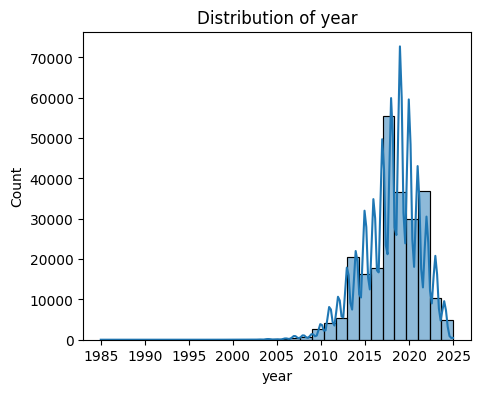

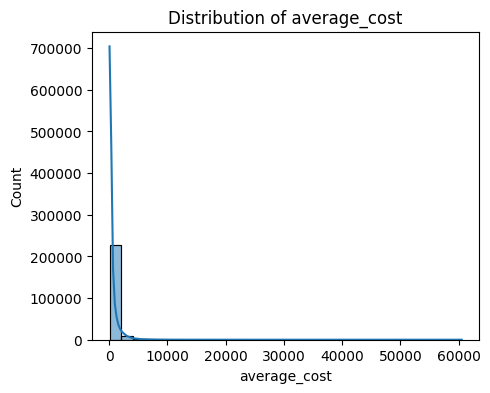

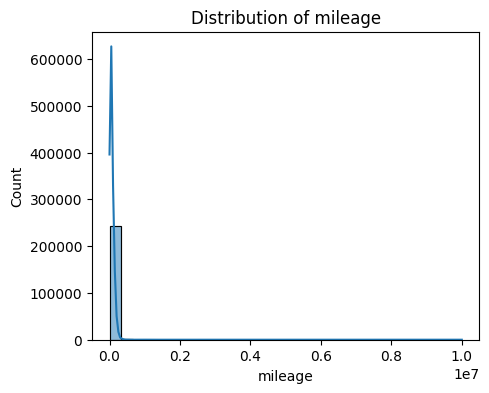

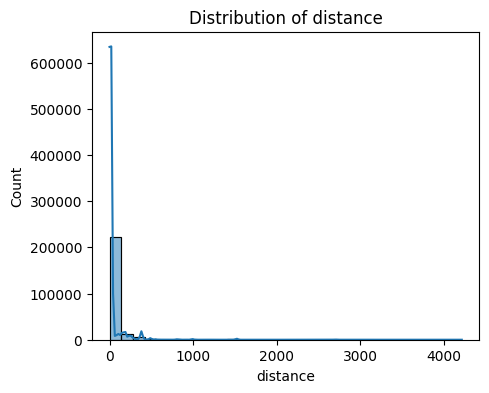

In [193]:
for col in numeric_cols:
  plt.figure(figsize=(5, 4))
  sns.histplot(df_copy[col].dropna(), kde=True, bins=30)
  plt.title(f"Distribution of {col}")
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.show()

The distribution of `year` is approximately bell-shaped but slightly left-skewed, with most observations clustered between 2014 and 2022, consistent with the mean (2018.0) and standard deviation (3.19 years). The service population is skewed toward newer vehicles that are more likely to be under warranty and engaged in routine dealership service, making vehicle year **a strong proxy for lifecycle stage, retention likelihood, and downstream purchase potential**.


Quantitatively, the `median` mileage is 52,128, while the mean is higher at 66,893, and the skew is exceptionally high (20.67), confirming that a small number of extreme values heavily distort the average. Most vehicles are at a typical serviceable stage of their lifecycle, while a small subset likely represents data entry errors, fleet vehicles, or unusually high-use cases.


For the `average_cost`, The histogram shows that most customers experience relatively low-cost services, while a minority face large bills exceeding 60,000. This reveals that average_cost captures price-shock risk, which is a likely **driver of non-return behavior**.


`Proximity` is common and likely associated with repeat service behavior, whereas long-distance visits are rare and likely represent one-time or opportunistic service events. This makes distance a critical friction variable for retention modeling.

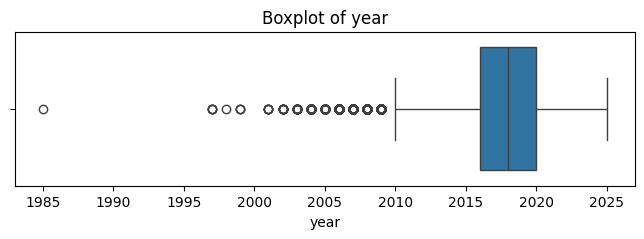

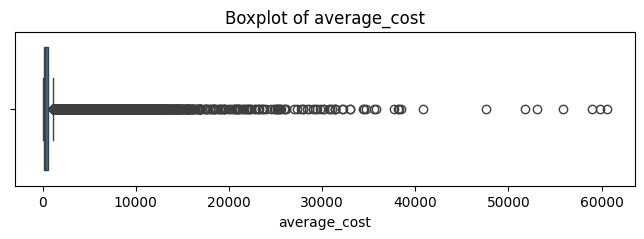

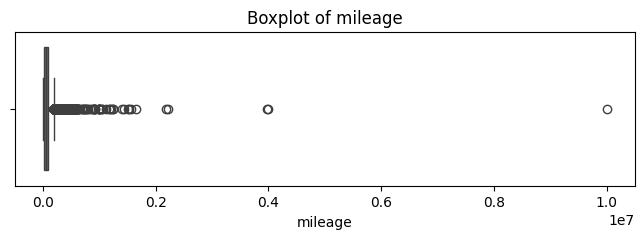

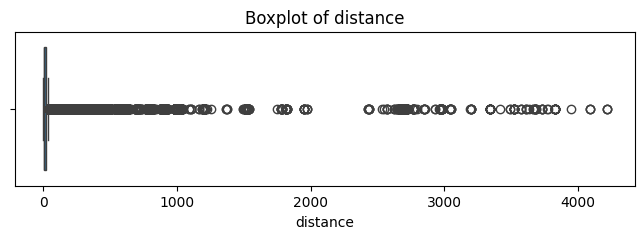

In [194]:
for col in numeric_cols:
  plt.figure(figsize=(8, 2))
  sns.boxplot(x=df_copy[col])
  plt.title(f"Boxplot of {col}")
  plt.show()

Now onto the cataegorical univariate analysis.

In [195]:
categorical_summary = []

for col in categorical_cols:
  value_counts = df_copy[col].value_counts()
  cardinality = df_copy[col].nunique()

  categorical_summary.append({
    "feature": col,
    "cardinality": cardinality,
    "top_category": value_counts.index[0] if len(value_counts) > 0 else None,
    "top_pct": value_counts.iloc[0] / len(df_copy),
    "missing_pct": df_copy[col].isnull().sum()
  })

categorical_summary_df = pd.DataFrame(categorical_summary)
categorical_summary_df

,feature,cardinality,top_category,top_pct,missing_pct
0,loyalty_card,2,No,0.823017,0
1,dealer_name,7,dealer_4,0.205676,0
2,make_clean,47,HONDA,0.200981,0
3,model_clean,893,CRV,0.070350,0
4,customer_pay,2,1,0.841908,0
5,warranty_pay,2,0,0.617633,0


* Several features are highly categorical, some binary, some with many levels.
* Some columns are dominated by a single category (e.g., loyalty_card).
* There are no missing values, so analysis won’t require imputation.
* This helps us decide how to visualize and summarize each categorical column.

Typically customers have no `loyalty_card`. It could be **interesting to group by loyalty card to see effect on cost**.

`dealer_name` isn't dominated by a single dealer, so **comparisons across dealers could be meaningful**. This seems like a good candidate for a bar plots of average costs or counts by dealer.

For `make_clean` we should maybe plot **top 10 makes** to avoid clutter. It would be useful for grouping models and plotting trends.

As for `model_clean`, we have a very high cardinality. There are too many unique models for standard bar plots, perhaps it would be better to focus on grouping by make or focus on the top models.

`customer_pay` for this feature, it would be interesting to analyze its **effect on cost via group comparisons**.

`warranty_pay` is binary, moderately imbalanced. We could **investigate the effect on average_cost**.

In [196]:
rare_category_summary = {}

for col in categorical_cols:
  freq = df_copy[col].value_counts(normalize=True)
  rare = freq[freq < 0.01]

  rare_category_summary[col] = {
    "num_rare_categories": len(rare),
    "rare_pct_total": rare.sum()
  }

pd.DataFrame(rare_category_summary).T

,num_rare_categories,rare_pct_total
loyalty_card,0.0,0.000000
dealer_name,0.0,0.000000
make_clean,39.0,0.020823
model_clean,865.0,0.353246
customer_pay,0.0,0.000000
warranty_pay,0.0,0.000000


Most categorical features have no rare categories, except for make_clean and model_clean, which have many low-frequency categories. For visualization and analysis, rare makes and models could be grouped as "other" to reduce clutter while preserving most of the dataset.

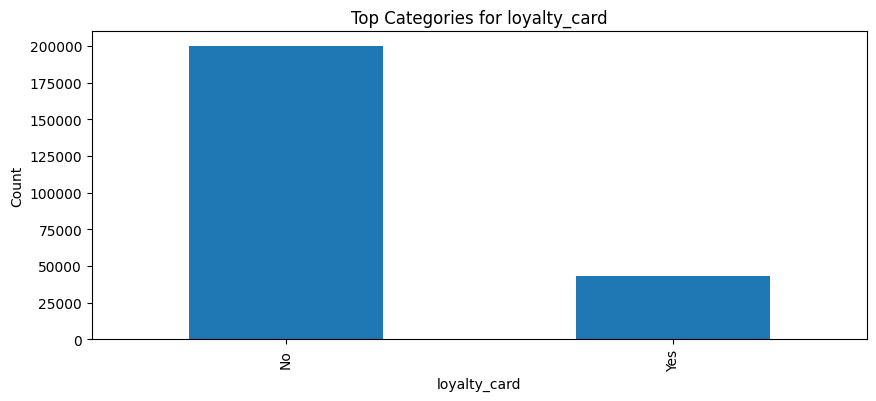

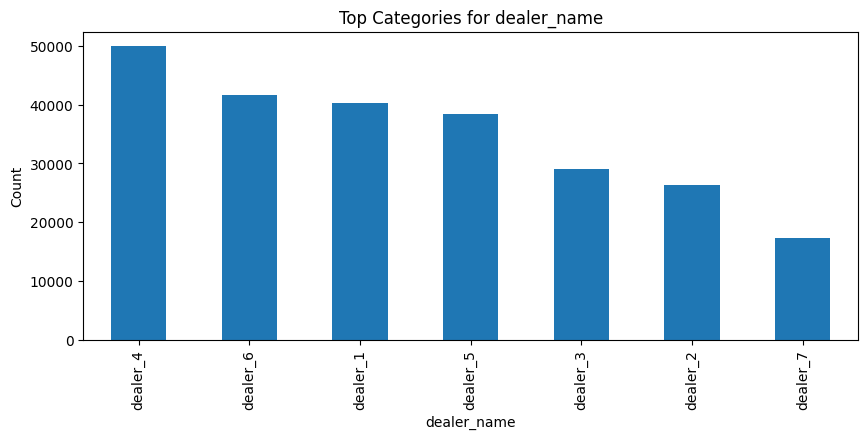

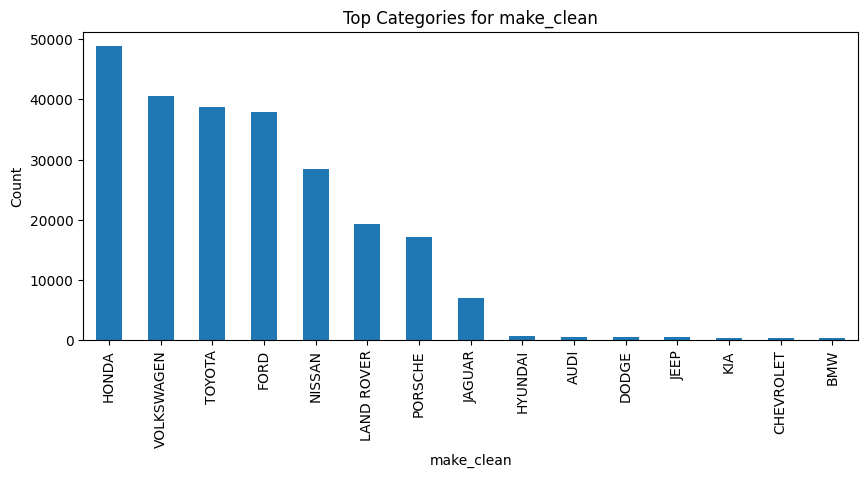

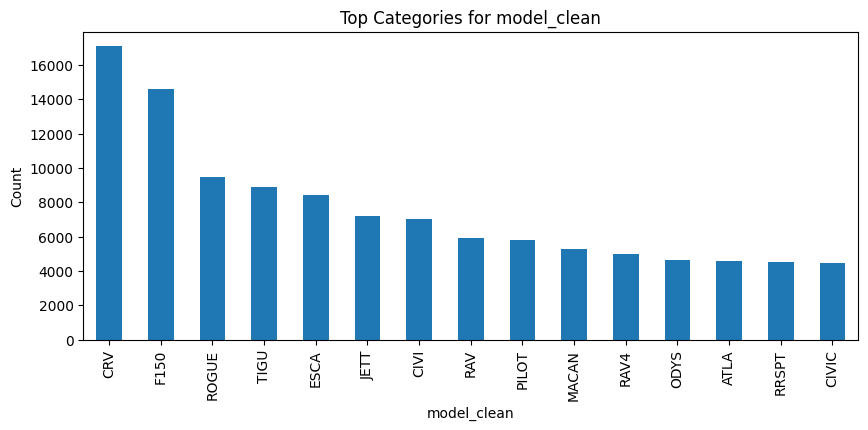

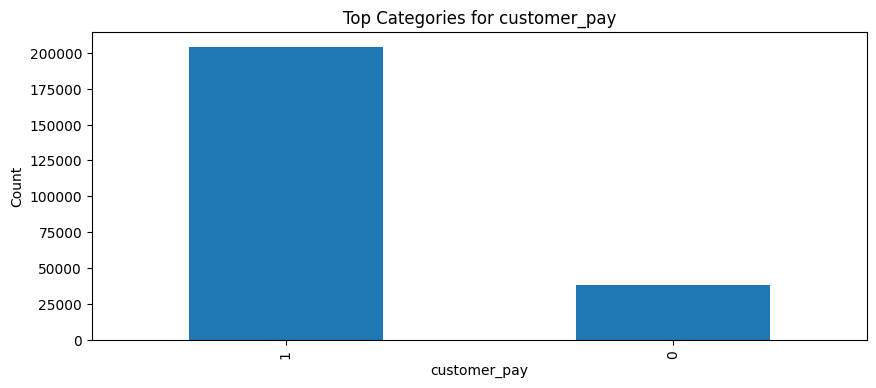

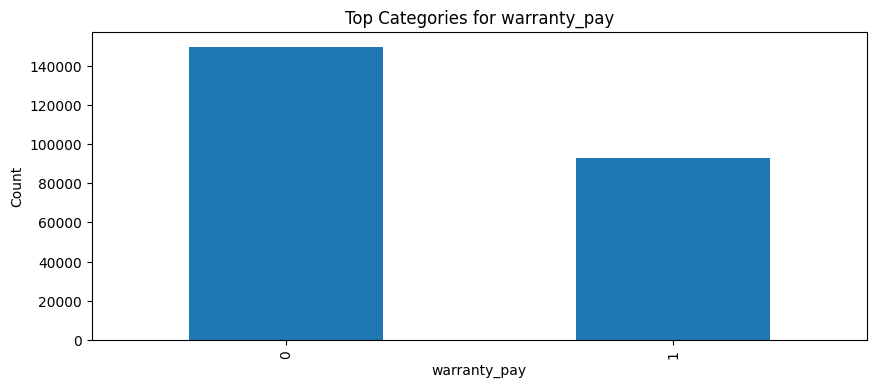

In [197]:
for col in categorical_cols:
  plt.figure(figsize=(10, 4))
  df_copy[col].value_counts().head(15).plot(kind="bar")
  plt.title(f"Top Categories for {col}")
  plt.ylabel("Count")
  plt.show()

`loyalty_card` is low-cardinality and highly interpretable behavioral variable. The dominant category (“No”) accounts for 82.3% of customers. This reveals a strong segmentation between a relatively small loyalty-card population and a much larger non-loyal group (loyalty enrollment is likely a strong predictor of repeat service behavior and a key lever for retention strategies.)

`dealer_name` is relatively balanced distribution that indicates that service volume is spread across multiple dealerships. This reveals that dealer-level differences in customer experience, convenience, or pricing may meaningfully influence service retention.

The `appointment` column is highly imbalanced: 83% of customers had an appointment, while 17% did not. Analyses comparing appointment status to cost or other variables should account for this imbalance. When plotting, we should use proportion (pie chart) or bar plots rather than histograms.

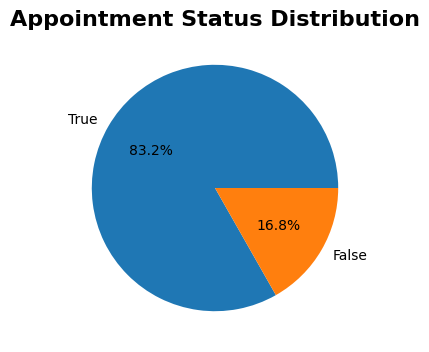

In [198]:
# Pie chart
df_copy['appointment'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(4, 4))
plt.title('Appointment Status Distribution',fontsize=16, fontweight='bold')
plt.ylabel('') # removes the default y-label
plt.show()


service_date
Min: 2020-01-01 00:00:00
Max: 2100-01-01 00:00:00
Coverage (days): 29220


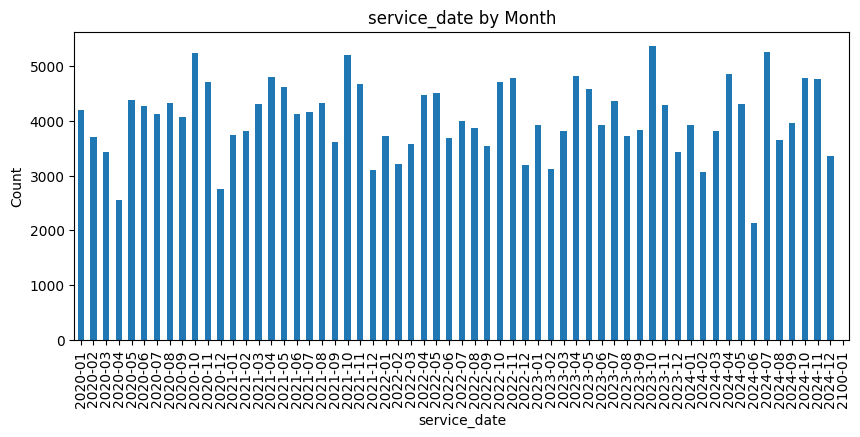


sale_date
Min: 2010-01-01 00:00:00
Max: 2024-12-01 00:00:00
Coverage (days): 5448


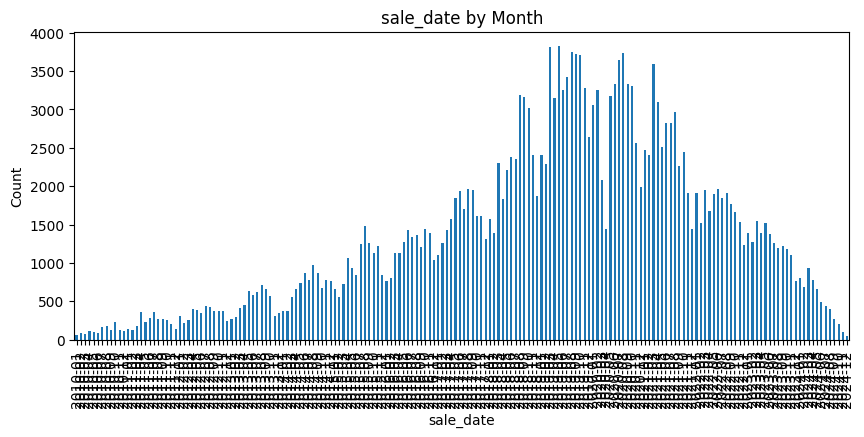

In [199]:
for col in datetime_cols:
  print(f"\n{col}")
  print("Min:", df_copy[col].min())
  print("Max:", df_copy[col].max())
  print("Coverage (days):", (df_copy[col].max() - df_copy[col].min()).days)

  plt.figure(figsize=(10, 4))
  df_copy[col].dt.to_period("M").value_counts().sort_index().plot(kind="bar")
  plt.title(f"{col} by Month")
  plt.ylabel("Count")
  plt.show()

The plot for `service_date` shows a stable monthly count of service events from January 2020. This indicates a steady stream of service activity over time, without obvious seasonal spikes or dips.Stability over time means that temporal drift or seasonality is less likely to confuse our retention model.

This second plot is interesting. `sale_date` reveals a clear growth trend in vehicle sales from 2010 to around 2018–2019, peaking around 3,800 sales in some months, then declining towards 2024. But *why is that?* is the question.

In [200]:
feature_personality = []

for col in numeric_cols:
    skew = df_copy[col].skew()
    outlier_pct = outlier_summary_df.loc[
        outlier_summary_df.feature == col, "outlier_pct"
    ].values[0]

    feature_personality.append({
        "feature": col,
        "type": "numeric",
        "skewed": abs(skew) > 1,
        "outliers_present": outlier_pct > 0.05,
        "cardinality": None,
        "rare_pct": None
    })

for col in categorical_cols:
    rare_pct = rare_category_summary[col]["rare_pct_total"]
    feature_personality.append({
        "feature": col,
        "type": "categorical",
        "skewed": None,
        "outliers_present": None,
        "cardinality": df_copy[col].nunique(),
        "rare_pct": rare_pct
    })

feature_personality_df = pd.DataFrame(feature_personality)
feature_personality_df.sort_values("type")


,feature,type,skewed,outliers_present,cardinality,rare_pct
4,loyalty_card,categorical,None,None,2.0,0.000000
5,dealer_name,categorical,None,None,7.0,0.000000
6,make_clean,categorical,None,None,47.0,0.020823
7,model_clean,categorical,None,None,893.0,0.353246
8,customer_pay,categorical,None,None,2.0,0.000000
9,warranty_pay,categorical,None,None,2.0,0.000000
0,year,numeric,False,False,NaN,NaN
1,average_cost,numeric,True,True,NaN,NaN
2,mileage,numeric,True,False,NaN,NaN
3,distance,numeric,True,True,NaN,NaN


Histograms and kernel density estimates were used to identify skewness and concentration, boxplots were used to detect outliers and threshold effects, and categorical value counts were used to assess dominance, rarity, and imbalance.

---
> Q1: Will customer return?
---
Could define this using VIN and service_date. For each VIN, sort by service date where we flag 1 if there is a subsequent service after the current one, 0 otherwise.


**Behavioral forces:**
1. friction variables (make returning harder)
    - distance, cost spikes, out-of-warranty status, ...
2. commitment variables (make returning more likely)
    - loyalty card, repeated vin history, ...

**Loyalty and Customer Commitment**

approximately 82% of customers do not have a loyalty card. Because enrollment is optional and not evenly distributed, it captures intentional engagement with the dealership, making it a strong explanatory feature for service retention.

**Distance**
* Median distance: 10.6 miles
* Mean distance: 43.1 miles
* Heavy right tail with extreme outliers

Most loyal service customers live close. Customers far away are often one-time or opportunistic visitors.

###Performing Outliers & Anomaly Investigation

Identify extreme values

Determine if they are errors or meaningful signals

Decide whether to keep, cap, or remove

Outliers often tell the most interesting stories.

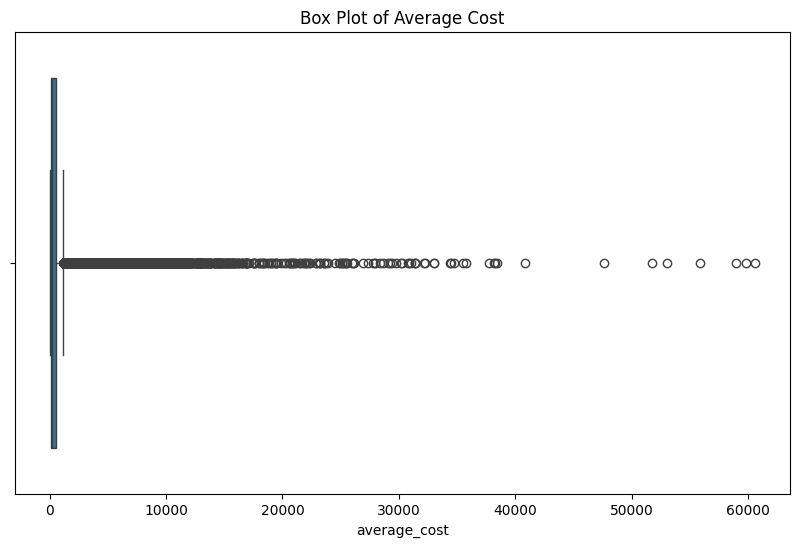

In [201]:
# check for outliers in the average_cost feature
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_copy['average_cost'])
plt.title('Box Plot of Average Cost')
plt.show()

This box plot shows that there are some thousands of outliers that exist. We didnt even know the average cost reached those particular value. We investigate further

In [202]:
# use Interquartile range formula to check for the outliers
Q1 = df_copy['average_cost'].quantile(0.25)
Q3 = df_copy['average_cost'].quantile(0.75)
IQR = Q3 - Q1


outliers = df_copy[df_copy['average_cost'] > Q3 + 1.5 * IQR]
print(f"There are {len(outliers)} outliers in the average_cost feature")
outliers



There are 28614 outliers in the average_cost feature


,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,average_cost,appointment,mileage,dealer_name,distance,make_clean,model_clean
2,2024-07-02,2020-03-01,1,1,2020,LAND,RR,9475224721,No,1300-1400,1350.0,True,66001,dealer_2,10.8,LAND ROVER,RR
15,2023-06-20,2023-02-01,1,0,2020,FORD,F150,1813236058,Yes,1900-2000,1950.0,True,99270,dealer_5,10.8,FORD,F150
49,2024-11-03,2024-10-01,1,1,2020,FORD,F150,3522781535,No,1400-1500,1450.0,True,141201,dealer_5,5.0,FORD,F150
57,2024-05-25,2024-04-01,1,1,2020,FORD,F150,3345623234,No,1200-1300,1250.0,True,82746,dealer_5,10.6,FORD,F150
67,2024-10-26,2023-06-01,1,1,2020,FORD,F150,4369214745,No,1700-1800,1750.0,True,83047,dealer_5,16.4,FORD,F150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242795,2021-02-20,2018-10-01,0,1,2018,FORD,F150,1632969767,No,1400-1500,1450.0,True,195885,dealer_5,2.4,FORD,F150
242803,2024-06-01,2023-02-01,1,0,2020,FORD,F150,1813236058,Yes,1300-1400,1350.0,True,121064,dealer_5,10.3,FORD,F150
242805,2023-05-09,2021-03-01,1,0,2016,FORD,F150,7785680981,Yes,4300-4400,4350.0,True,171311,dealer_5,11.9,FORD,F150
242812,2023-12-16,2018-01-01,1,0,2017,FORD,F150,7180708356,Yes,4400-4500,4450.0,True,258558,dealer_5,329.4,FORD,F150


In [203]:
# Looking at the top 10 average_cost entries
df_copy.nlargest(10, 'average_cost')


,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,average_cost,appointment,mileage,dealer_name,distance,make_clean,model_clean
181668,2022-12-16,2020-10-01,0,1,2020,PORS,TAYCAN,9175135924,No,60500-60600,60550.0,False,11477,dealer_7,25.7,PORSCHE,TAYCAN
134884,2022-01-29,2020-08-01,1,1,2020,PORS,TAYCAN,7459259288,No,59800-59900,59850.0,True,14225,dealer_7,5.7,PORSCHE,TAYCAN
181679,2021-01-08,2020-12-01,0,1,2020,PORS,TAYCAN,3840325662,No,58900-59000,58950.0,False,20,dealer_7,592.5,PORSCHE,TAYCAN
181535,2024-12-10,2021-01-01,1,1,2020,PORS,TAYCAN,8100464819,No,55800-55900,55850.0,False,50400,dealer_7,20.1,PORSCHE,TAYCAN
142947,2023-02-03,2014-06-01,1,1,2015,PORS,MACAN,9435912198,No,53000-53100,53050.0,True,112801,dealer_7,271.0,PORSCHE,MACAN
148494,2023-05-06,2022-10-01,0,1,2023,JAGU,FPACE,4660593386,No,51700-51800,51750.0,True,12230,dealer_2,8.0,JAGUAR,FPACE
142540,2024-12-24,2020-02-01,1,1,2020,PORS,MACAN,9084517214,No,47600-47700,47650.0,True,72555,dealer_7,11.0,PORSCHE,MACAN
171347,2024-04-02,2022-08-01,1,1,2022,TOYO,TUND,2204634503,No,40800-40900,40850.0,False,44041,dealer_1,264.8,TOYOTA,TUND
132625,2023-05-06,2021-02-01,0,1,2021,LAND,DEFEN,2113553273,No,38400-38500,38450.0,True,36841,dealer_2,25.8,LAND ROVER,DEFEN
96370,2024-06-07,2022-11-01,1,1,2023,TOYO,TUND,9721775664,Yes,38200-38300,38250.0,True,31859,dealer_1,15.5,TOYOTA,TUND


Looking at those outliers, they are not erroneous. The story of the dataset tells us that the car make and year led to more expensive service costs.

Next, we will look for outliers in distance and mileage. That could tell us about the customers and their vehicle "personality"

Now, let's look at how many people have loyalty cards using a pie chart

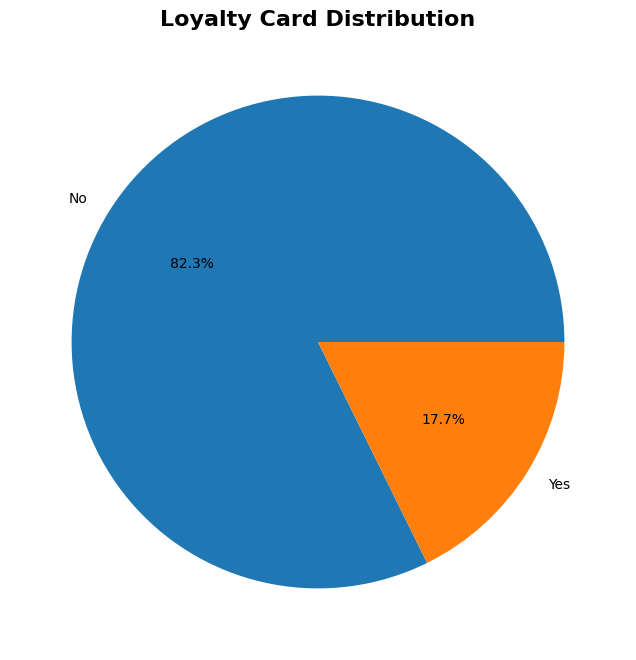

In [204]:
df_copy['loyalty_card'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))
plt.title('Loyalty Card Distribution',fontsize=16, fontweight='bold')
plt.ylabel('') # removes the default y-label
plt.show()

Looking at the pie chart, it is clear that a majority of the people do not have the loyalty card. Or rather, do not use it for services.

This could imply that the customers do not really see the value of getting a loyalty card.

Then the question becomes, "How can we convince customers to get and use their loyalty cards?"
Maybe using the example of Costco's membership strategy to make it somewhat compulsory to use the loyalty card and really let them experience the benefits of using it instantaneously.

We shall analyse the behavior of people with loyalty cards to see how the transaction history is with the company.

Also, check to see if a customer uses a loyalty card and then, does not use it for subsequent transaction. This should be a huge red flag, as you want the customer to feel like they cannot go to the Auto Service business without their membership, kind of like Costco

# Problem 1. Retention strategy
At this point, it is time for us to look at the use cases given to us.
1. Retention Strategy: Identify customers who are at high risk of not returning and target them with reminders, promotions, or loyalty offers.

So, who is a customer at high risk of not returning? It would be someone that follows similar pattern of people that stopped coming after a short period of time. So, first identify those type of customers.

Now, each unique VIN should have a unique sales date. If this isn't the case, then the car was resold. This would be a good sign because the customer came back to the business to sell the car


In [205]:
""" Need to populate missing values in the average_cost column by looking
at the vehicle make and the dealership. Look for other vehicles of the same vehicle make and the same dealership,
get the average and replace the missing values"""
missing_avg_cost = df_copy['average_cost'].isnull()
df_copy.loc[missing_avg_cost, ['make_clean', 'year', 'dealer_name', 'average_cost']]

,make_clean,year,dealer_name,average_cost
1436,FORD,2011,dealer_5,NaN
1437,FORD,2011,dealer_5,NaN
18401,FORD,2015,dealer_3,NaN
23116,HYUNDAI,2015,dealer_3,NaN
23153,HYUNDAI,2012,dealer_3,NaN
...,...,...,...,...
226394,TOYOTA,2018,dealer_3,NaN
226478,TOYOTA,2024,dealer_1,NaN
234883,FORD,2012,dealer_5,NaN
239975,FORD,2018,dealer_5,NaN


In [206]:
# Replace null values for the mean of entries that align with the make, year and dealership

df_copy['average_cost'] = df_copy.groupby(['make_clean', 'year','dealer_name'])['average_cost'].transform(lambda x: x.fillna(x.mean()))

 # for 1 row that had GMC but couldn't fit the above criteria
df_copy['average_cost'] = df_copy.groupby(['make_clean', 'year'])['average_cost'].transform(lambda x: x.fillna(x.mean()))

In [207]:
df_copy["average_cost"].isnull().sum()

np.int64(0)

In [208]:
# Ensure each unique vin has only one sales date
if df_copy.groupby('vin')['sale_date'].nunique().eq(1).all():

    print("Each unique vin has only one sales date.")
else:
    print("Not all unique vins have only one sales date.")

Not all unique vins have only one sales date.


In [209]:
# Use the ne method to get a boolean return for vins with more than one unique sales date
violations = df_copy.groupby('vin')['sale_date'].nunique().ne(1)

# Use the .any method to check if there are any true in the boolean series
if violations.any():
    print("Some vins have multiple sale dates:")

    # Print the vin
    print(df_copy.groupby('vin')['sale_date'].nunique()[violations].sort_values(ascending = False))
else:
    print("Each unique vin has only one sales date.")


Some vins have multiple sale dates:
vin
9104277000    4
7487931709    4
7214072537    4
4559194691    3
6282009497    3
             ..
4151622788    2
4152143169    2
4158258573    2
4166831692    2
4135878975    2
Name: sale_date, Length: 2802, dtype: int64


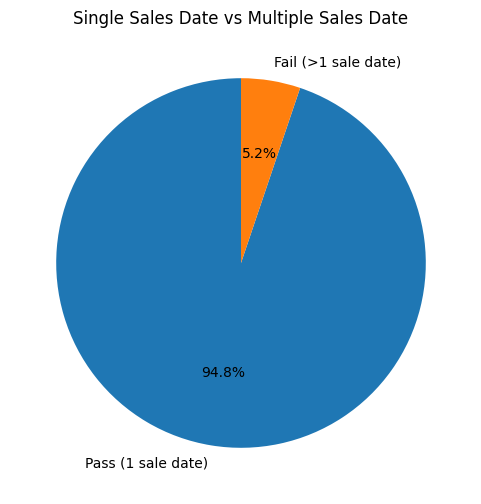

In [210]:
# Count unique sale dates per VIN
unique_counts = df_copy.groupby('vin')['sale_date'].nunique()

# Pass/fail classification
pass_fail = unique_counts.eq(1).value_counts() # Counts how many true and false there are

# Rename for clarity
pass_fail.index = ['Pass (1 sale date)', 'Fail (>1 sale date)']

# Plot
plt.figure(figsize=(6, 6))
plt.pie(pass_fail, labels=pass_fail.index, autopct='%1.1f%%', startangle=90)
plt.title("Single Sales Date vs Multiple Sales Date")
plt.show()



Now we have identified the type of customers the company wants. People that come and sell their vehicles they bought from the company and the company is able to resell them.

Our hypothesis here is that a customer that sells the car to the business is either doing a trade in or the car was repoed


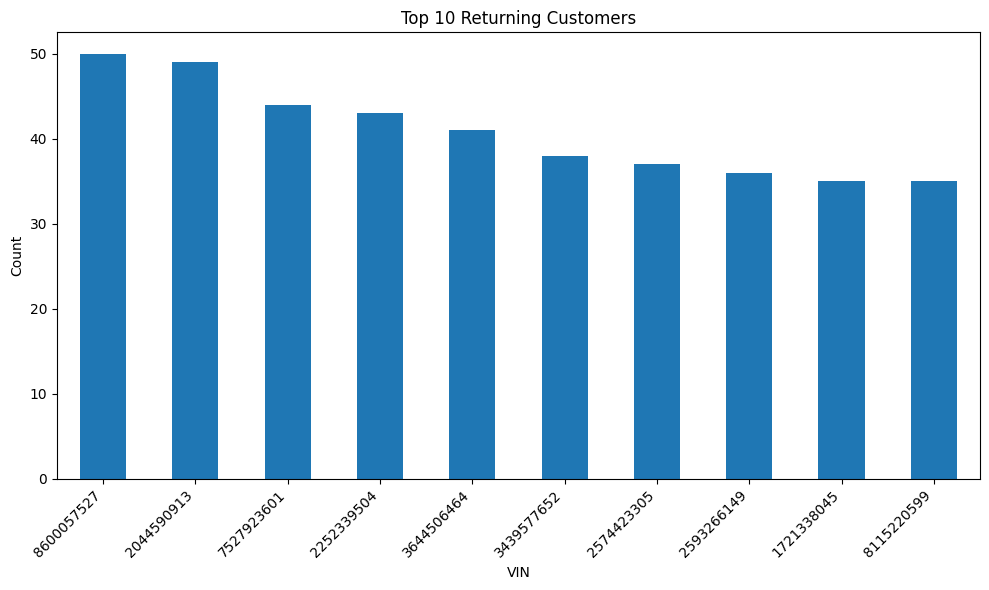

In [211]:
top_10_customers = df_copy.groupby("vin").size().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_10_customers.plot(kind="bar")
plt.xlabel("VIN")
plt.ylabel("Count")
plt.title("Top 10 Returning Customers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [212]:
top_10 = top_10_customers.index

cars_for_top_10 = (
    df_copy[df_copy["vin"].isin(top_10)]
    .drop_duplicates(subset=["vin", "make", "model", "year"])
    .sort_values("vin")
)



In [213]:
cars_for_top_10[["vin","make_clean","model_clean","year","loyalty_card","warranty_pay","dealer_name"]]

,vin,make_clean,model_clean,year,loyalty_card,warranty_pay,dealer_name
36444,1721338045,HONDA,CIVI,2020,No,1,dealer_4
17417,2044590913,FORD,EDGE,2013,No,1,dealer_5
98122,2252339504,TOYOTA,CAMHYB,2019,No,1,dealer_1
98562,2574423305,TOYOTA,CAMRY,2018,No,0,dealer_1
15129,2593266149,FORD,EXPL,2020,No,1,dealer_5
91822,3439577652,TOYOTA,RAV4HY,2019,Yes,0,dealer_1
87617,3439577652,TOYOTA,RAV,2019,No,0,dealer_1
120963,3644506464,VOLKSWAGEN,GOLF,2016,No,0,dealer_6
112696,7527923601,VOLKSWAGEN,GW6G,2015,No,0,dealer_6
11884,8115220599,FORD,ESCA,2015,No,0,dealer_5


In [214]:
one_time_customers = df_copy.groupby("vin").size() == 1
one_time_customers.sum()


np.int64(14461)

In [215]:
one_time_customers

,0
vin,
1000167976,False
1000197869,False
1000286137,True
1000350530,False
1000402957,False
...,...
9999004471,False
9999309465,False
9999638691,False


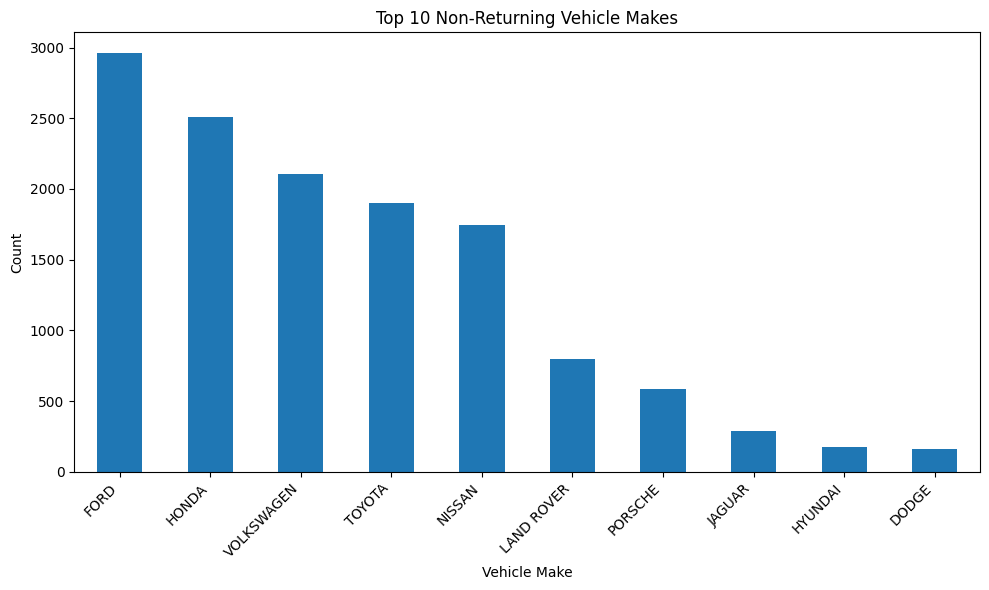

In [216]:
# What are the top ten vehicle makes they drive?
one_time_customers_vmake =(
    df_copy[df_copy["vin"].isin(one_time_customers[one_time_customers].index)]["make_clean"]
    .value_counts()
    .sort_values(ascending=False)
    .head(10)
)


plt.figure(figsize=(10, 6))
one_time_customers_vmake.plot(kind="bar")
plt.xlabel("Vehicle Make")
plt.ylabel("Count")
plt.title("Top 10 Non-Returning Vehicle Makes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [217]:
# Create a table to show return count of vehicles
return_count = df_copy.groupby("vin").size().sort_values(ascending=False)

# What is the Statistics of the return column
return_count.describe()

,0
count,54050.000000
mean,4.492396
std,4.022636
min,1.000000
25%,1.000000
50%,3.000000
75%,6.000000
max,50.000000


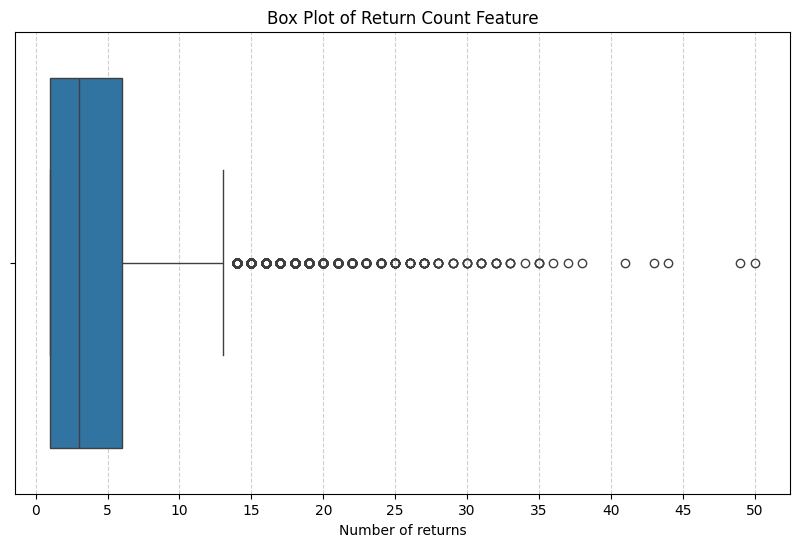

In [218]:
# visualize the distribution of return count
plt.figure(figsize=(10, 6))
sns.boxplot(x=return_count)
plt.title('Box Plot of Return Count Feature')
plt.xlabel('Number of returns')
plt.grid(True, axis='x', linestyle='--', alpha=0.6) # for grid linee
max_val = return_count.max()
plt.xticks(range(0, max_val + 5, 5))
plt.show()

In [219]:
# get the number of outliers in the return count feature

Q1 = return_count.quantile(0.25)
Q3 = return_count.quantile(0.75)
IQR = Q3 - Q1

upper_fence = Q3 + 1.5 * IQR

outliers = return_count[return_count > upper_fence].nunique()
outliers


30

In [220]:
# Applying labels to the return count by service_year and mapping it back to the main df_copy

# ensure service_year exists
df_copy['service_year'] = pd.to_datetime(df_copy['service_date']).dt.year

# 1) count returns per (service_year, vin)
return_count = df_copy.groupby(['service_year', 'vin']).size()

# 2) build a df and categorize per service_year
return_df = return_count.to_frame('return_count')

return_df['return_category'] = (
    return_df
    .groupby(level=0)['return_count']   # level=0 is 'service_year'
    .transform(lambda x: pd.cut(
        x,
        # Ensure bins are monotonically increasing.
        # The last bin needs to be strictly greater than 6.
        # We add 1 to `max(x.max(), 6)` to ensure strict monotonicity and cover the actual max.
        bins=[-1, 2, 6, max(x.max(), 6) + 1],
        labels=['low_return', 'medium_return', 'high_return'],
        right=True
    ))
)

# 3) create tuple key in df_copy and map using MultiIndex
df_copy['return_category'] = list(
    map(
        return_df['return_category'].get,
        zip(df_copy['service_year'], df_copy['vin'])
    )
)


# drop erroneous date entry
df_copy = df_copy[df_copy['service_date'] != '2100-01-01']
df_copy.head()

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,average_cost,appointment,mileage,dealer_name,distance,make_clean,model_clean,service_year,return_category
0,2024-07-29,2021-04-01,1,0,2021,TOYO,RAV4HY,3395527356,Yes,200-300,250.0,True,39076,dealer_1,9.0,TOYOTA,RAV4HY,2024,medium_return
1,2024-07-30,2023-12-01,1,1,2024,TOYO,RAV4HY,5296888873,Yes,0-100,50.0,True,39556,dealer_1,12.0,TOYOTA,RAV4HY,2024,high_return
2,2024-07-02,2020-03-01,1,1,2020,LAND,RR,9475224721,No,1300-1400,1350.0,True,66001,dealer_2,10.8,LAND ROVER,RR,2024,low_return
3,2024-07-03,2023-07-01,1,1,2018,NISS,PATH,3446880696,No,500-600,550.0,True,82454,dealer_3,15.3,NISSAN,PATH,2024,low_return
4,2022-10-30,2011-05-01,1,0,2008,FORD,FUSN,5577514554,No,0-100,50.0,True,5,dealer_5,4.8,FORD,FUSN,2022,medium_return


<Figure size 1200x600 with 0 Axes>

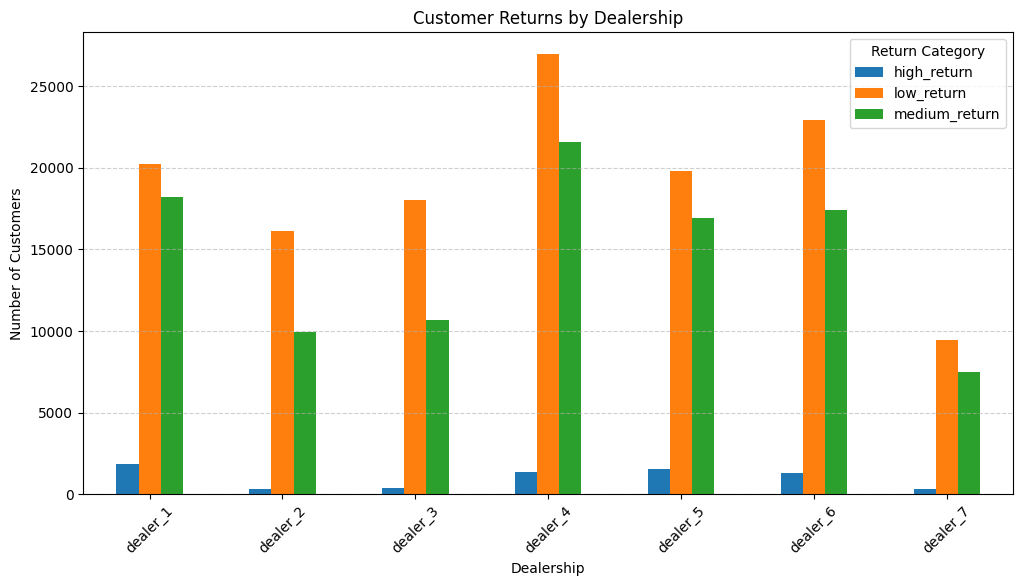

In [221]:
# Get the distribution of vins via the return category for each dealership
dealers_return = df_copy.groupby(['dealer_name', 'return_category']).size().unstack(fill_value=0)


plt.figure(figsize=(12, 6))
dealers_return.plot(kind='bar', figsize=(12, 6))

plt.title('Customer Returns by Dealership')
plt.xlabel('Dealership')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.legend(title='Return Category')

plt.show()



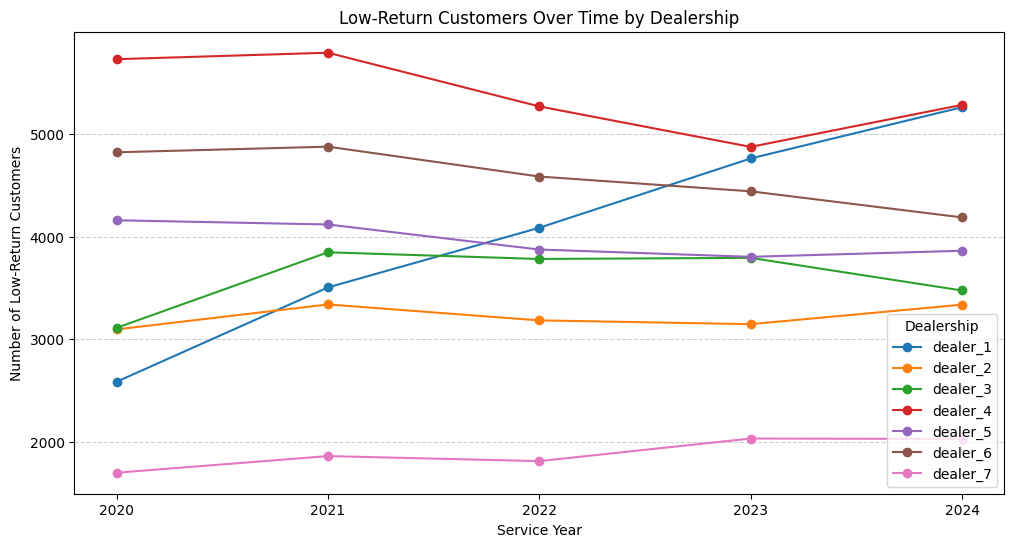

In [222]:
# For each dealership, determine when all return categories come for their next service
low_return_trend = (
    df_copy[df_copy['return_category'] == 'low_return']
    .groupby([df_copy['service_date'].dt.year, 'dealer_name',])
    .size()
    .unstack(fill_value=0).sort_index()
)

# Plot the graph
plt.figure(figsize=(12, 6))

for dealer in low_return_trend.columns:
    plt.plot(low_return_trend.index, low_return_trend[dealer], marker='o', label=dealer)

plt.title('Low-Return Customers Over Time by Dealership')
plt.xlabel('Service Year')
plt.ylabel('Number of Low-Return Customers')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Dealership')
plt.xticks(low_return_trend.index)

plt.show()


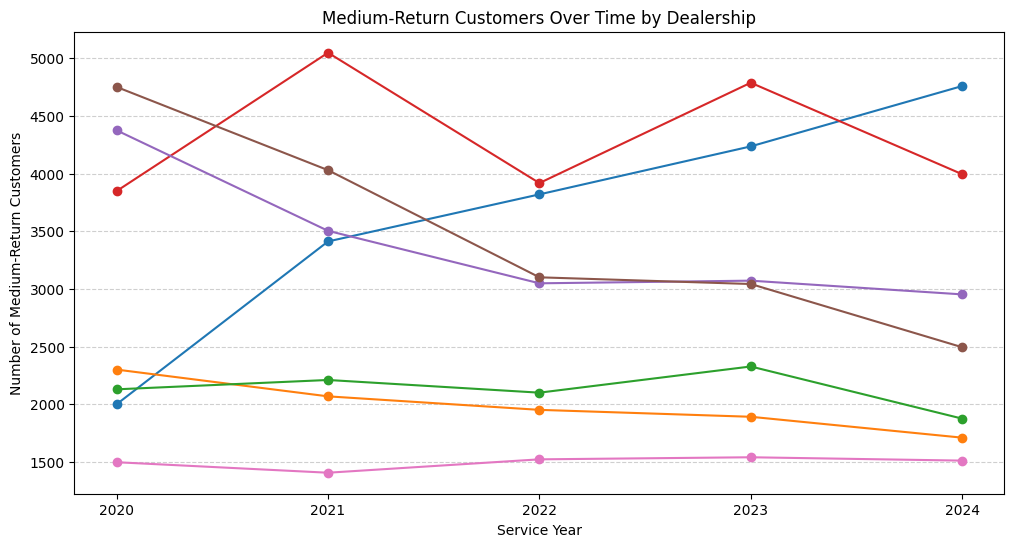

In [223]:
medium_return_trend = (
    df_copy[df_copy['return_category'] == 'medium_return']
    .groupby([df_copy['service_date'].dt.year, 'dealer_name'])
    .size()
    .unstack(fill_value=0).sort_index()
)

# Plot the graph
plt.figure(figsize=(12, 6))

for dealer in medium_return_trend.columns:
    plt.plot(medium_return_trend.index, medium_return_trend[dealer], marker='o', label=dealer)

plt.title('Medium-Return Customers Over Time by Dealership')
plt.xlabel('Service Year')
plt.ylabel('Number of Medium-Return Customers')

plt.grid(axis='y', linestyle='--', alpha=0.6)
#plt.legend(title='Dealership')
plt.xticks(medium_return_trend.index)

plt.show()


#Visualizations


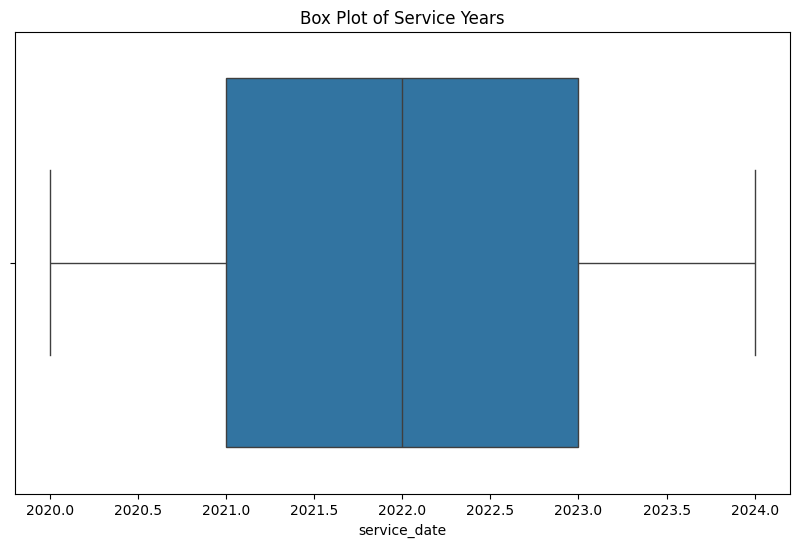

In [224]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_copy['service_date'].dt.year)
plt.title('Box Plot of Service Years')
plt.show()

In [225]:
# locate the outlier

df_copy[df_copy['service_date'].dt.year == 2100]

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,average_cost,appointment,mileage,dealer_name,distance,make_clean,model_clean,service_year,return_category


In [226]:
# Bring out all transactions by that vin number

date_outlier = df_copy[df_copy['vin'] == 7702609663].sort_values('service_date')
date_outlier

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,average_cost,appointment,mileage,dealer_name,distance,make_clean,model_clean,service_year,return_category
153835,2020-04-26,2019-12-01,1,0,2019,VW,TIGUAN,7702609663,No,200-300,250.000000,False,15142,dealer_6,241.0,VOLKSWAGEN,TIGUAN,2020,medium_return
119147,2020-04-28,2019-12-01,1,1,2019,VW,TIGUAN,7702609663,No,100-200,150.000000,True,15142,dealer_6,239.7,VOLKSWAGEN,TIGUAN,2020,medium_return
120729,2020-07-13,2019-12-01,1,0,2019,VW,TIGUAN,7702609663,No,200-300,250.000000,True,30203,dealer_6,239.5,VOLKSWAGEN,TIGUAN,2020,medium_return
120731,2020-08-23,2019-12-01,1,0,2019,VW,TIGUAN,7702609663,No,200-300,250.000000,True,44952,dealer_6,239.9,VOLKSWAGEN,TIGUAN,2020,medium_return
215451,2020-11-08,2019-12-01,1,1,2019,VW,TIGUAN,7702609663,No,300-400,350.000000,True,61294,dealer_6,240.7,VOLKSWAGEN,TIGUAN,2020,medium_return
215461,2021-01-30,2019-12-01,1,1,2019,VW,TIGUAN,7702609663,No,200-300,250.000000,True,89791,dealer_6,239.3,VOLKSWAGEN,TIGUAN,2021,low_return
176692,2021-01-31,2019-12-01,0,1,2019,VW,TIGUAN,7702609663,No,NaN,493.590123,False,89797,dealer_6,239.9,VOLKSWAGEN,TIGUAN,2021,low_return
120380,2022-01-02,2019-12-01,1,0,2019,VW,TIGUAN,7702609663,No,700-800,750.000000,True,120479,dealer_6,240.1,VOLKSWAGEN,TIGUAN,2022,low_return
120066,2023-03-31,2019-12-01,1,0,2019,VW,TIGUAN,7702609663,No,100-200,150.000000,True,192009,dealer_6,240.5,VOLKSWAGEN,TIGUAN,2023,low_return


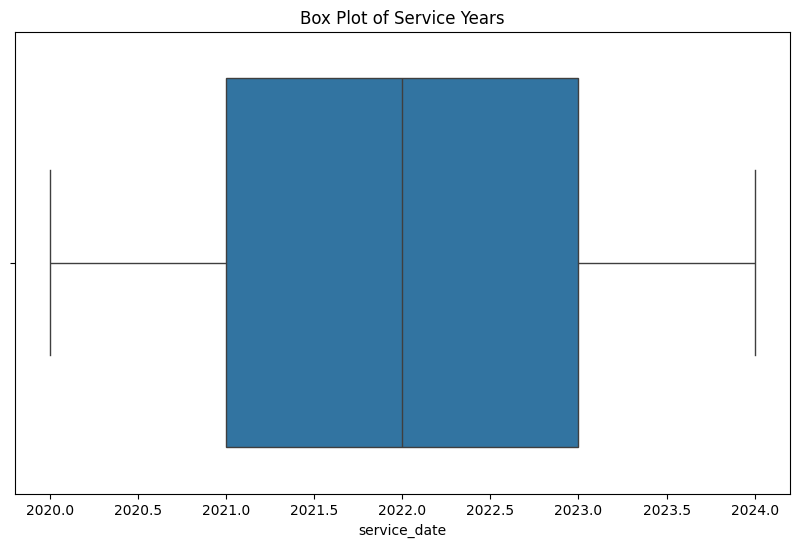

In [227]:
# replace  back in the main df_copy

df_copy.loc[df_copy['service_date'].dt.year == 2100, 'service_date'] = pd.to_datetime(predicted_date)

plt.figure(figsize=(10, 6))
sns.boxplot(x=df_copy['service_date'].dt.year)
plt.title('Box Plot of Service Years')
plt.show()


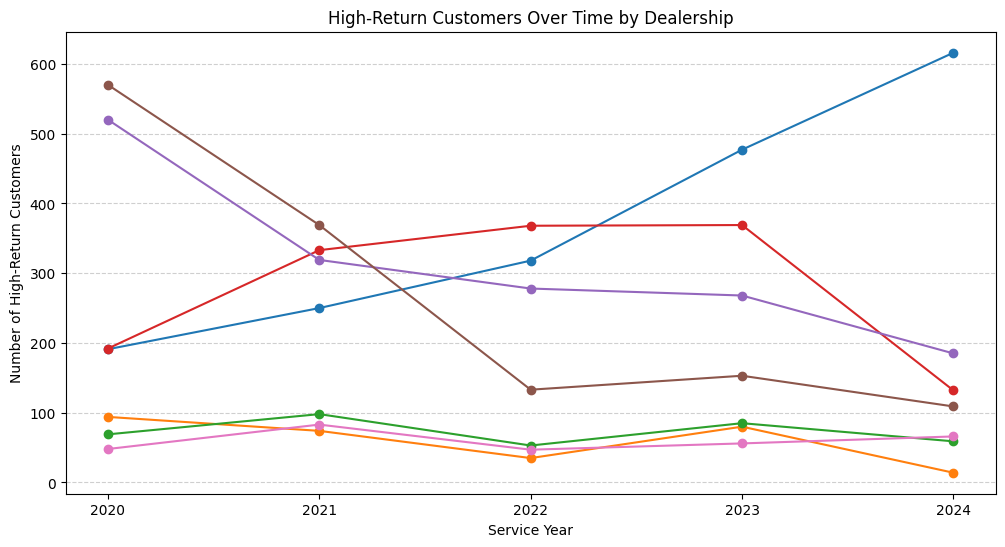

In [228]:
high_return_trend = (
    df_copy[df_copy['return_category'] == 'high_return']
    .groupby([df_copy['service_date'].dt.year, 'dealer_name'])
    .size()
    .unstack(fill_value=0).sort_index()
)

# Plot the graph
plt.figure(figsize=(12, 6))

for dealer in high_return_trend.columns:
    plt.plot(high_return_trend.index, high_return_trend[dealer], marker='o', label=dealer)

plt.title('High-Return Customers Over Time by Dealership')
plt.xlabel('Service Year')
plt.ylabel('Number of High-Return Customers')

plt.grid(axis='y', linestyle='--', alpha=0.6)
#plt.legend(title='Dealership')
plt.xticks(high_return_trend.index)

plt.show()

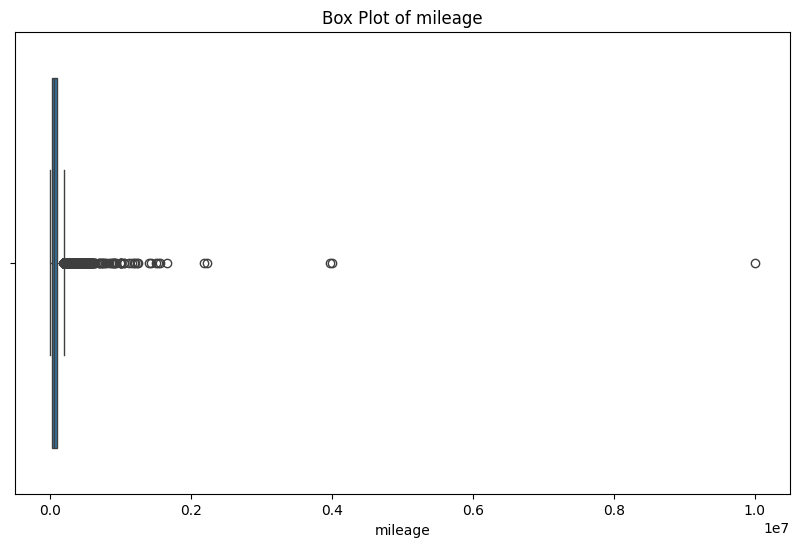

In [229]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_copy['mileage'])
plt.title('Box Plot of mileage')
plt.show()

In [230]:
df_copy["mileage"].describe()

,mileage
count,2.428130e+05
mean,6.689286e+04
std,6.255489e+04
min,0.000000e+00
25%,2.398500e+04
50%,5.212800e+04
75%,9.496700e+04
max,1.000000e+07


In [231]:
df_copy.sort_values('mileage')

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,average_cost,appointment,mileage,dealer_name,distance,make_clean,model_clean,service_year,return_category
186686,2022-12-25,2012-12-01,1,0,2007,HYUN,SANT,3082500977,No,400-500,450.0,False,0,dealer_4,8.2,HYUNDAI,SANT,2022,low_return
165937,2021-01-30,2020-12-01,0,1,2019,HOND,CIVIC,4265186122,No,800-900,850.0,False,0,dealer_4,18.2,HONDA,CIVIC,2021,low_return
57485,2021-02-12,2012-02-01,1,1,2011,HOND,RIDG,4653016165,No,100-200,150.0,True,0,dealer_4,6.1,HONDA,RIDG,2021,medium_return
176944,2020-07-07,2015-08-01,0,1,2015,VW,TIGUAN,3795058529,No,1800-1900,1850.0,False,0,dealer_6,241.1,VOLKSWAGEN,TIGUAN,2020,medium_return
149086,2020-10-23,2019-07-01,1,0,2016,AUDI,A4,2250792462,No,0-100,50.0,True,0,dealer_4,15.6,AUDI,A4,2020,low_return
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53009,2020-01-06,2014-09-01,1,0,2010,HOND,ACCO,5763239747,No,0-100,50.0,True,2180056,dealer_4,23.0,HONDA,ACCO,2020,low_return
223844,2023-01-11,2022-02-01,1,0,2010,HOND,ACCO,4871196610,No,300-400,350.0,True,2222278,dealer_4,3.7,HONDA,ACCO,2023,low_return
45324,2024-11-02,2013-03-01,1,0,2013,HOND,PILOT,6753559559,No,100-200,150.0,True,3980002,dealer_4,14.7,HONDA,PILOT,2024,medium_return
52135,2024-11-26,2023-04-01,1,0,2006,HOND,ACCO,5357181595,Yes,300-400,350.0,True,4000000,dealer_4,23.0,HONDA,ACCO,2024,low_return


In [232]:
df_copy[df_copy['vin']==7018021125].sort_values('service_date')

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,average_cost,appointment,mileage,dealer_name,distance,make_clean,model_clean,service_year,return_category
67109,2020-08-05,2018-10-01,1,1,2014,NISS,PATH,7018021125,No,10200-10300,10250.0,True,83410,dealer_3,5.6,NISSAN,PATH,2020,low_return
155073,2021-03-23,2018-10-01,0,1,2014,NISS,PATH,7018021125,No,100-200,150.0,False,10000000,dealer_3,4.8,NISSAN,PATH,2021,low_return
67066,2021-09-17,2018-10-01,0,1,2014,NISS,PATH,7018021125,No,100-200,150.0,True,89333,dealer_3,4.1,NISSAN,PATH,2021,low_return
206849,2022-06-11,2018-10-01,1,1,2014,NISS,PATH,7018021125,No,900-1000,950.0,True,93142,dealer_3,5.3,NISSAN,PATH,2022,low_return
67145,2022-11-13,2018-10-01,1,1,2014,NISS,PATH,7018021125,No,300-400,350.0,True,93696,dealer_3,6.0,NISSAN,PATH,2022,low_return
206401,2023-04-28,2018-10-01,1,1,2014,NISS,PATH,7018021125,Yes,300-400,350.0,True,94603,dealer_3,5.7,NISSAN,PATH,2023,low_return
67087,2023-09-29,2018-10-01,0,1,2014,NISS,PATH,7018021125,No,100-200,150.0,True,101341,dealer_3,4.9,NISSAN,PATH,2023,low_return


In [233]:
df_copy[df_copy['vin']==5357181595]

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,average_cost,appointment,mileage,dealer_name,distance,make_clean,model_clean,service_year,return_category
52077,2023-12-10,2023-04-01,1,0,2006,HOND,ACCO,5357181595,Yes,800-900,850.0,True,205535,dealer_4,21.4,HONDA,ACCO,2023,low_return
52135,2024-11-26,2023-04-01,1,0,2006,HOND,ACCO,5357181595,Yes,300-400,350.0,True,4000000,dealer_4,23.0,HONDA,ACCO,2024,low_return


In [234]:

Q1 = df_copy['mileage'].quantile(0.25)
Q3 = df_copy['mileage'].quantile(0.75)
IQR = Q3 - Q1

upper_fence = Q3 + 1.5 * IQR

mileage_outliers_count = df_copy['mileage'][df_copy['mileage'] > upper_fence].nunique()
mileage_outliers_count


6479

In [235]:
upper_fence

np.float64(201440.0)

Text(0.5, 1.0, "Box plot of Mileage outlier's Outliers")

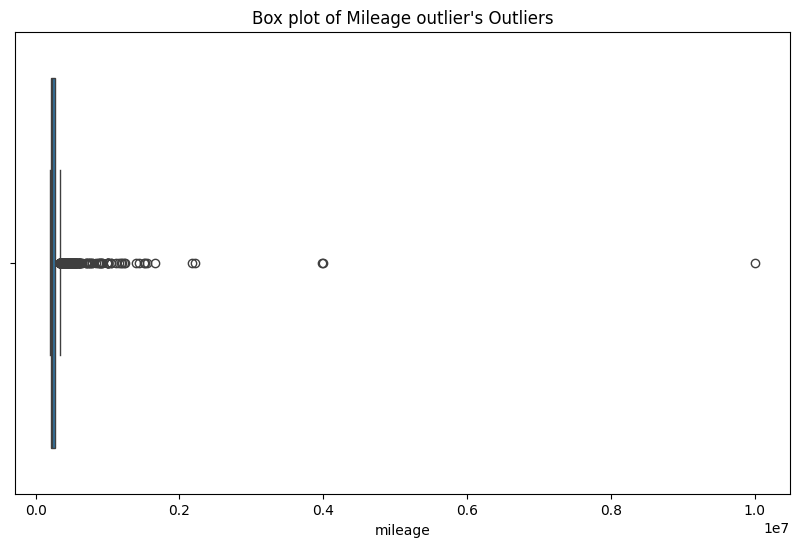

In [236]:
mileage_outliers = df_copy[df_copy['mileage'] > upper_fence]


plt.figure(figsize=(10, 6))
sns.boxplot(x=mileage_outliers['mileage'])
plt.title("Box plot of Mileage outlier's Outliers")

In [237]:
df_copy[(df_copy['mileage'] < 1000000) & (df_copy['mileage'] > 341209.5)].shape[0]

449

In [238]:
Q1 = mileage_outliers['mileage'].quantile(0.25)
Q3 = mileage_outliers['mileage'].quantile(0.75)
IQR = Q3 - Q1

upper_fence = Q3 + 1.5 * IQR

mileage_outliers_count_2 = mileage_outliers['mileage'][mileage_outliers['mileage'] > upper_fence].nunique()
mileage_outliers_count_2

456

Text(0.5, 1.0, "Box plot of Mileage outlier's Outlier's Outliers")

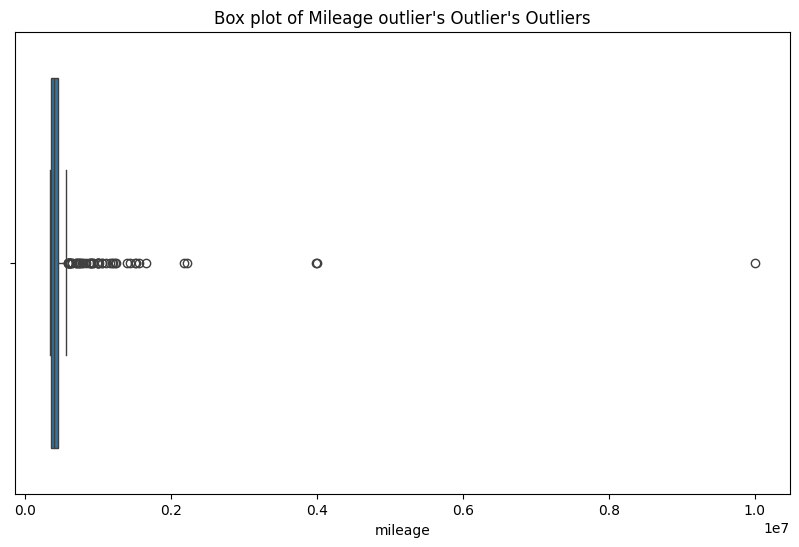

In [239]:

mileage_outliers_2 = mileage_outliers[mileage_outliers['mileage'] > upper_fence]

plt.figure(figsize=(10, 6))
sns.boxplot(x=mileage_outliers_2['mileage'])
plt.title("Box plot of Mileage outlier's Outlier's Outliers")

In [240]:
df_copy[(df_copy["mileage"] > 1000000)].shape[0]

22

In [241]:
df_copy[(df_copy["mileage"] > 1000000)]

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,average_cost,appointment,mileage,dealer_name,distance,make_clean,model_clean,service_year,return_category
100,2024-07-30,2024-03-01,1,0,2019,FORD,F150,5941662458,Yes,0-100,50.0,True,1053369,dealer_5,16.8,FORD,F150,2024,low_return
44781,2020-10-03,2016-04-01,1,0,2016,HOND,PILOT,8300814804,No,200-300,250.0,True,1113297,dealer_4,13.8,HONDA,PILOT,2020,medium_return
45324,2024-11-02,2013-03-01,1,0,2013,HOND,PILOT,6753559559,No,100-200,150.0,True,3980002,dealer_4,14.7,HONDA,PILOT,2024,medium_return
52135,2024-11-26,2023-04-01,1,0,2006,HOND,ACCO,5357181595,Yes,300-400,350.0,True,4000000,dealer_4,23.0,HONDA,ACCO,2024,low_return
53009,2020-01-06,2014-09-01,1,0,2010,HOND,ACCO,5763239747,No,0-100,50.0,True,2180056,dealer_4,23.0,HONDA,ACCO,2020,low_return
53233,2020-11-07,2015-10-01,1,0,2014,HOND,ACCO,3652841325,No,200-300,250.0,True,1502588,dealer_4,3.3,HONDA,ACCO,2020,low_return
56002,2020-03-14,2013-09-01,1,0,2013,HOND,FIT,2099575369,No,400-500,450.0,True,1525414,dealer_4,18.6,HONDA,FIT,2020,low_return
81630,2024-01-15,2020-08-01,1,0,2020,TOYO,RAV4,8988772172,No,100-200,150.0,True,1242382,dealer_1,5.5,TOYOTA,RAV4,2024,medium_return
86888,2024-03-05,2019-04-01,1,0,2019,TOYO,RAV,2038081731,Yes,400-500,450.0,True,1554526,dealer_1,13.4,TOYOTA,RAV,2024,low_return
131844,2021-10-27,2015-08-01,1,0,2015,LAND,LR4,3101567934,No,1900-2000,1950.0,True,1656753,dealer_2,11.3,LAND ROVER,LR4,2021,medium_return


In [242]:
outliers_history = df_copy[(df_copy["mileage"] > 1000000)].groupby("vin").size()
outliers_history

,0
vin,
2033687014,1
2038081731,1
2099575369,1
3101567934,1
3651131955,1
3652841325,1
4719610529,1
4871196610,1
5171855214,1


In [243]:
df_copy = df_copy[df_copy['mileage'] < 1000000]

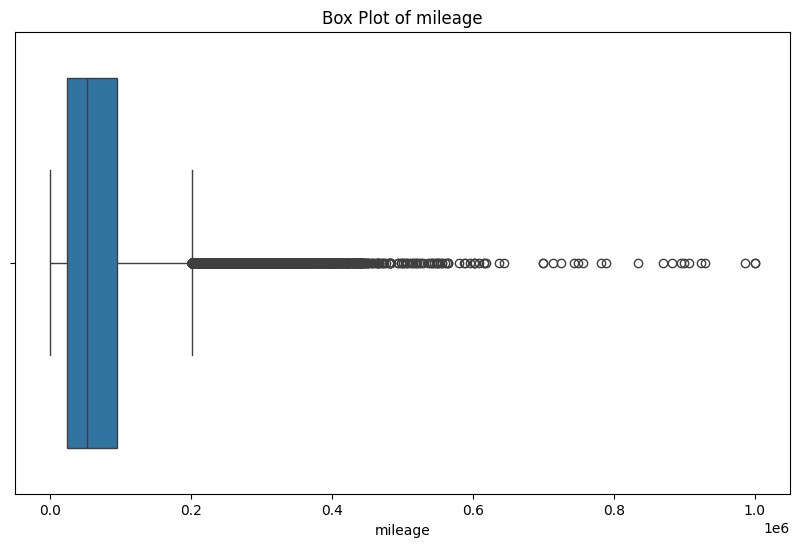

In [244]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_copy['mileage'])
plt.title('Box Plot of mileage')
plt.show()

In [245]:
Q1 = df_copy['mileage'].quantile(0.25)
Q3 = df_copy['mileage'].quantile(0.75)
IQR = Q3 - Q1

upper_fence = Q3 + 1.5 * IQR

mileage_outliers_count = df_copy['mileage'][df_copy['mileage'] > upper_fence].nunique()
mileage_outliers_count

6462

In [246]:
df_cleaned = df_copy.drop(['make','model','cost'],axis=1)
df_cleaned

,service_date,sale_date,customer_pay,warranty_pay,year,vin,loyalty_card,average_cost,appointment,mileage,dealer_name,distance,make_clean,model_clean,service_year,return_category
0,2024-07-29,2021-04-01,1,0,2021,3395527356,Yes,250.0,True,39076,dealer_1,9.0,TOYOTA,RAV4HY,2024,medium_return
1,2024-07-30,2023-12-01,1,1,2024,5296888873,Yes,50.0,True,39556,dealer_1,12.0,TOYOTA,RAV4HY,2024,high_return
2,2024-07-02,2020-03-01,1,1,2020,9475224721,No,1350.0,True,66001,dealer_2,10.8,LAND ROVER,RR,2024,low_return
3,2024-07-03,2023-07-01,1,1,2018,3446880696,No,550.0,True,82454,dealer_3,15.3,NISSAN,PATH,2024,low_return
4,2022-10-30,2011-05-01,1,0,2008,5577514554,No,50.0,True,5,dealer_5,4.8,FORD,FUSN,2022,medium_return
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242813,2023-09-18,2023-02-01,1,0,2020,1813236058,Yes,1450.0,True,104768,dealer_5,10.2,FORD,F150,2023,medium_return
242814,2020-04-17,2017-08-01,1,0,2017,6891633666,No,350.0,False,99848,dealer_5,4.0,FORD,F150,2020,medium_return
242815,2021-02-12,2015-05-01,1,0,2015,1516333102,No,350.0,False,110669,dealer_5,24.4,FORD,F150,2021,medium_return
242816,2021-01-20,2019-01-01,1,0,2018,5245369000,No,250.0,False,66496,dealer_5,5.7,FORD,F150,2021,low_return


In [247]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 242791 entries, 0 to 242817
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   service_date     242791 non-null  datetime64[ns]
 1   sale_date        242791 non-null  datetime64[ns]
 2   customer_pay     242791 non-null  int64         
 3   warranty_pay     242791 non-null  int64         
 4   year             242791 non-null  int64         
 5   vin              242791 non-null  int64         
 6   loyalty_card     242791 non-null  object        
 7   average_cost     242791 non-null  float64       
 8   appointment      242791 non-null  bool          
 9   mileage          242791 non-null  int64         
 10  dealer_name      242791 non-null  object        
 11  distance         242791 non-null  float64       
 12  make_clean       242791 non-null  object        
 13  model_clean      242791 non-null  object        
 14  service_year     242791 n

# Features For ML Modelling

In [248]:
# Vehicle Age at Service
df_cleaned['vehicle_age_at_service'] = df_cleaned['service_year'] - df_cleaned['year']

# How long after purchase did the customer return
df_cleaned['days_since_purchase'] = (
    df_cleaned['service_date'] - df_cleaned['sale_date']
).dt.days

# Service Month to determine seasonality
df_cleaned['service_month'] = df_cleaned['service_date'].dt.month

# Service day of the week to identify customer scheduling behavior
df_cleaned['service_dayofweek'] = df_cleaned['service_date'].dt.dayofweek

# determine weekend service
df_cleaned['is_weekend'] = (df_cleaned['service_date'].dt.dayofweek >= 5).astype(int)

# Time since last service (Very Importatnt)
df_ = df_cleaned.sort_values(['vin','service_date'])
df_cleaned['days_since_last_service'] = (
    df_.groupby('vin')['service_date']
    .diff()
    .dt.days
)
df_cleaned['days_since_last_service'] = df_cleaned['days_since_last_service'].fillna(0)

# Number of services per VIN over the entire span of the dataset
df_cleaned['service_number'] = df_.groupby('vin').cumcount() + 1

# loyalty_card times distance to determine commitment even within certain distance
df_cleaned['loyalty_binary'] = df_cleaned['loyalty_card'].map({'Yes':1, 'No':0})
df_cleaned['distance_loyalty_interaction'] = df_cleaned['distance'] * df_cleaned['loyalty_binary']

# Only use this code when testing for data leakage using Group Split method
# df_cleaned = df_cleaned.sort_values(['vin', 'service_date']).copy()

# next service date for the same VIN
df_cleaned['next_service_date'] = df_cleaned.groupby('vin')['service_date'].shift(-1)

# target: did they come back after this visit?
df_cleaned['next_return'] = df_cleaned['next_service_date'].notna().astype(int)

# a column to differentiate off-make service vs on-make service
df_cleaned['on_make_service'] = (
    df_cleaned.apply(
        lambda row: (
            isinstance(row['dealer_name'], str)
            and isinstance(row['make_clean'], str)
            and row['make_clean'].lower() in row['dealer_name'].lower()
        ),
        axis=1
    )
    .fillna(False)
    .astype(int)
) # Note that on_make_service is being removed because it becomes meaningless when the dealership info becomes anonymized.


df_cleaned = df_cleaned.drop(['service_date','sale_date','next_service_date','loyalty_card','return_category','model_clean','on_make_service','vin'],axis=1)
df_cleaned.head()

,customer_pay,warranty_pay,year,average_cost,appointment,mileage,dealer_name,distance,make_clean,service_year,vehicle_age_at_service,days_since_purchase,service_month,service_dayofweek,is_weekend,days_since_last_service,service_number,loyalty_binary,distance_loyalty_interaction,next_return
0,1,0,2021,250.0,True,39076,dealer_1,9.0,TOYOTA,2024,3,1215,7,0,0,189.0,5,1,9.0,1
1,1,1,2024,50.0,True,39556,dealer_1,12.0,TOYOTA,2024,0,242,7,1,0,23.0,5,1,12.0,1
2,1,1,2020,1350.0,True,66001,dealer_2,10.8,LAND ROVER,2024,4,1584,7,1,0,510.0,4,0,0.0,1
3,1,1,2018,550.0,True,82454,dealer_3,15.3,NISSAN,2024,6,368,7,2,0,180.0,3,0,0.0,1
4,1,0,2008,50.0,True,5,dealer_5,4.8,FORD,2022,14,4200,10,6,1,8.0,6,0,0.0,1


In [249]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 242791 entries, 0 to 242817
Data columns (total 20 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   customer_pay                  242791 non-null  int64  
 1   warranty_pay                  242791 non-null  int64  
 2   year                          242791 non-null  int64  
 3   average_cost                  242791 non-null  float64
 4   appointment                   242791 non-null  bool   
 5   mileage                       242791 non-null  int64  
 6   dealer_name                   242791 non-null  object 
 7   distance                      242791 non-null  float64
 8   make_clean                    242791 non-null  object 
 9   service_year                  242791 non-null  int32  
 10  vehicle_age_at_service        242791 non-null  int64  
 11  days_since_purchase           242791 non-null  int64  
 12  service_month                 242791 non-null  in

In [250]:
# export dataframe into csv file
df_cleaned.to_csv('df_cleaned.csv', index=False)